<a href="https://colab.research.google.com/github/halimAhtasham/Network-_Intrusion_Detection---All_In_One/blob/main/Binary_Classification_on_NIDS_with_ROSIDS23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**01. Import libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

**02. Load Dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_PATH = "/content/drive/MyDrive/Datasets/ROSIDS23.csv"
df = pd.read_csv(DATA_PATH)

print(df.shape)

(136681, 84)


In [4]:
print(df.info())
print("\n")
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136681 entries, 0 to 136680
Data columns (total 84 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Flow ID            136681 non-null  object 
 1   Src IP             136681 non-null  object 
 2   Src Port           136681 non-null  int64  
 3   Dst IP             136681 non-null  object 
 4   Dst Port           136681 non-null  int64  
 5   Protocol           136681 non-null  int64  
 6   Timestamp          136681 non-null  object 
 7   Flow Duration      136681 non-null  int64  
 8   Tot Fwd Pkts       136681 non-null  int64  
 9   Tot Bwd Pkts       136681 non-null  int64  
 10  TotLen Fwd Pkts    136681 non-null  float64
 11  TotLen Bwd Pkts    136681 non-null  float64
 12  Fwd Pkt Len Max    136681 non-null  float64
 13  Fwd Pkt Len Min    136681 non-null  float64
 14  Fwd Pkt Len Mean   136681 non-null  float64
 15  Fwd Pkt Len Std    136681 non-null  float64
 16  Bw

**03. Initial Inspection**

In [5]:
print("Rows: ", df.shape[0])
print("Columns: ", df.shape[1])

Rows:  136681
Columns:  84


In [6]:
df.columns.tolist()

['Flow ID',
 'Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pkt Size Avg',
 '

In [7]:
df.dtypes.tolist()

[dtype('O'),
 dtype('O'),
 dtype('int64'),
 dtype('O'),
 dtype('int64'),
 dtype('int64'),
 dtype('O'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64')

In [8]:
df.dtypes.value_counts()

,count
float64,45
int64,34
object,5


In [9]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

,0
Flow Byts/s,272


In [10]:
numeric_df = df.select_dtypes(include=np.number)

infinite_values = np.isinf(numeric_df).sum()

infinite_values[infinite_values > 0].sort_values(ascending=False)

,0
Flow Pkts/s,275
Flow Byts/s,3


In [11]:
print("Duplicate Rows: ", df.duplicated().sum())

Duplicate Rows:  0


In [12]:
df["Label"].value_counts()

,count
Label,
Benign,62511
DoS,31000
Subflood,30064
UnauthPub,7817
UnauthSub,5289


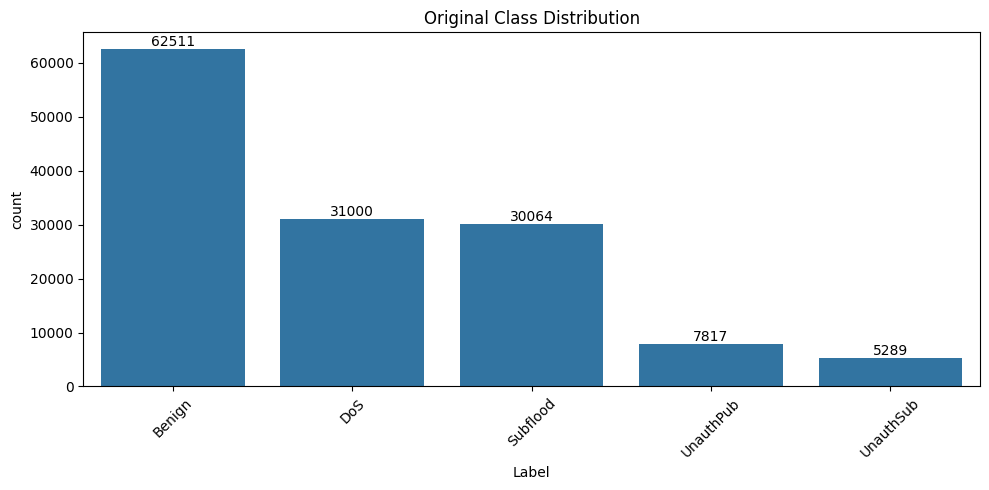

In [13]:
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x="Label", order=df["Label"].value_counts().index)
ax.bar_label(ax.containers[0])

plt.title("Original Class Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **04. Leakage Analysis**

In [14]:
possible_identifier_columns = [
    "Flow ID",
    "Src IP",
    "Dst IP",
    "Timestamp"
]

for col in possible_identifier_columns:
  if col in df.columns:
    print(f"{col}:")
    print(df[col].head())
    print("\n")

Flow ID:
0    192.168.3.4-192.168.3.6-11311-60792-6
1    192.168.3.4-192.168.3.6-11311-60794-6
2    192.168.3.4-192.168.3.6-11311-39922-6
3    192.168.3.4-192.168.3.6-11311-55266-6
4    192.168.3.6-192.168.3.7-43770-11111-6
Name: Flow ID, dtype: object


Src IP:
0    192.168.3.6
1    192.168.3.6
2    192.168.3.6
3    192.168.3.6
4    192.168.3.7
Name: Src IP, dtype: object


Dst IP:
0    192.168.3.4
1    192.168.3.4
2    192.168.3.4
3    192.168.3.4
4    192.168.3.6
Name: Dst IP, dtype: object


Timestamp:
0    07/07/2023 02:10:23 PM
1    07/07/2023 02:10:23 PM
2    07/07/2023 02:10:32 PM
3    07/07/2023 02:11:11 PM
4    07/07/2023 02:10:03 PM
Name: Timestamp, dtype: object




In [15]:
for col in possible_identifier_columns:
  if col in df.columns:
    unique_ratio = df[col].nunique() / len(df)
    print(f"{col}: {df[col].unique()} unique values " f"({unique_ratio:.2%} unique)")
    print("\n")

Flow ID: ['192.168.3.4-192.168.3.6-11311-60792-6'
 '192.168.3.4-192.168.3.6-11311-60794-6'
 '192.168.3.4-192.168.3.6-11311-39922-6' ...
 '192.168.3.4-192.168.3.10-40241-52098-6'
 '192.168.3.6-239.255.255.250-46286-1900-17'
 '192.168.3.6-239.255.255.250-39959-1900-17'] unique values (52.53% unique)


Src IP: ['192.168.3.6' '192.168.3.7' '192.168.3.4' '8.6.0.1' '192.168.3.10'
 '192.168.3.14'] unique values (0.00% unique)


Dst IP: ['192.168.3.4' '192.168.3.6' '192.168.3.7' '224.0.0.7' '8.0.6.4'
 '224.0.0.251' '239.255.255.250' '255.255.255.255' '192.168.3.10'] unique values (0.01% unique)


Timestamp: ['07/07/2023 02:10:23 PM' '07/07/2023 02:10:32 PM'
 '07/07/2023 02:11:11 PM' ... '2023-07-12 12:29:52' '2023-07-12 12:29:34'
 '2023-07-12 13:13:52'] unique values (9.97% unique)




# **05. Data Cleaning**

In [16]:
# Remove leakage Prone Columns

leakage_columns = [
    "Flow ID",
    "Src IP",
    "Dst IP",
    "Timestamp"
]

df_clean = df.drop(columns=leakage_columns, errors="ignore").copy()

print("Removed Columns: ")
print(leakage_columns)

print("\nNew Dataset Shape: ")
print(df_clean.shape)

Removed Columns: 
['Flow ID', 'Src IP', 'Dst IP', 'Timestamp']

New Dataset Shape: 
(136681, 80)


In [17]:
df_clean.head()

,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,60792,11311,6,6260,5,5,60.0,30.0,30.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,60794,11311,6,5903,5,5,60.0,30.0,30.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,39922,11311,6,4523,5,5,60.0,30.0,30.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,55266,11311,6,5191,5,5,60.0,30.0,30.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,11111,43770,6,72625778,2200,2212,41320.0,18526.0,30.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [18]:
# Separate Target

X = df_clean.drop(columns=["Label"]).copy()
y_original = df_clean["Label"].copy()

print("Features: ", X.shape)
print("Target: ", y_original.shape)

Features:  (136681, 79)
Target:  (136681,)


In [19]:
y_original.value_counts()

,count
Label,
Benign,62511
DoS,31000
Subflood,30064
UnauthPub,7817
UnauthSub,5289


In [20]:
# Replace Infinite Values

X = X.replace([np.inf, -np.inf], np.nan)
print(X.isnull().sum().sum())

550


In [21]:
# Constant Features

constant_features = [
    col for col in X.columns
    if X[col].nunique(dropna=False) <= 1
]

print("Number of constant features: ", len(constant_features))
print("\nConstant Features: ")
print(constant_features)

Number of constant features:  14

Constant Features: 
['Fwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Init Fwd Win Byts', 'Fwd Seg Size Min']


In [22]:
X = X.drop(columns=constant_features)

print("Shape after removing constant features: ")
print(X.shape)

Shape after removing constant features: 
(136681, 65)


In [23]:
# Check data types

print(X.dtypes.value_counts())

float64    45
int64      20
Name: count, dtype: int64


In [24]:
non_numeric_columns = X.select_dtypes(exclude=np.number).columns.tolist()

print("Non-numeric columns:")
print(non_numeric_columns)

Non-numeric columns:
[]


In [25]:
print(X.shape)
print(X.isnull().sum().sum())

(136681, 65)
550


In [26]:
# 5.6 Final Cleaning Inspection

print("Dataset shape:", X.shape)

print("\nTotal missing values:")
print(X.isnull().sum().sum())

print("\nTotal infinite values:")
print(np.isinf(X.select_dtypes(include=np.number)).sum().sum())

print("\nDuplicate rows:")
print(X.duplicated().sum())

Dataset shape: (136681, 65)

Total missing values:
550

Total infinite values:
0

Duplicate rows:
385


# **06. Anomaly Creation (Binary Label)**

In [27]:
from matplotlib.colors import Normalize
# create binary target

y = (y_original != "Benign").astype(int)

print("Binary class Distribution: ")
print(y.value_counts())
print("\n")
print(y.value_counts(normalize=True))

Binary class Distribution: 
Label
1    74170
0    62511
Name: count, dtype: int64


Label
1    0.54265
0    0.45735
Name: proportion, dtype: float64


In [28]:
class_distribution = y.value_counts().sort_index()
class_percentage = y.value_counts(normalize=True).sort_index() * 100

distribution_df = pd.DataFrame({
    "Count" : class_distribution,
    "Percentage" : class_percentage.round(2)
})
distribution_df.index = ["Benign[0]", "Attack[1]"]
distribution_df

,Count,Percentage
Benign[0],62511,45.73
Attack[1],74170,54.27


In [29]:
# mapping

verification = pd.DataFrame({
    "Original_Label" : y_original,
    "Binary_Label" : y
})

pd.crosstab(
    verification["Original_Label"],
    verification["Binary_Label"]
)

Binary_Label,0,1
Original_Label,,
Benign,62511,0
DoS,0,31000
Subflood,0,30064
UnauthPub,0,7817
UnauthSub,0,5289


**07. Dataset Preparaton Check**

In [30]:
print("X shape ", X.shape)
print("y shape ", y.shape)

print(len(X) == len(y))

X shape  (136681, 65)
y shape  (136681,)
True


# **08. Train - Test Split**

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set: ", X_train.shape)
print("Testing set: ", X_test.shape)
print("\n")
print("Training Label: ", y_train.value_counts())
print("\n")
print("Test Label: ", y_test.value_counts())

Training set:  (109344, 65)
Testing set:  (27337, 65)


Training Label:  Label
1    59336
0    50008
Name: count, dtype: int64


Test Label:  Label
1    14834
0    12503
Name: count, dtype: int64


In [32]:
print("training class distribution: ")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\n")
print("test class distribution: ")
print((y_test.value_counts(normalize=True) * 100).round(2))

training class distribution: 
Label
1    54.27
0    45.73
Name: proportion, dtype: float64


test class distribution: 
Label
1    54.26
0    45.74
Name: proportion, dtype: float64


# **09. Cross Validation Setup**

In [33]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Cross validation strategy:")
print(cv)

Cross validation strategy:
StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [34]:
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), 1):
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    print(f"\nFold {fold}")
    print(f"Training samples:   {len(train_idx)}")
    print(f"Validation samples: {len(val_idx)}")

    print(
        f"Train attack ratio: "
        f"{y_fold_train.mean():.4f}"
    )

    print(
        f"Validation attack ratio: "
        f"{y_fold_val.mean():.4f}"
    )


Fold 1
Training samples:   87475
Validation samples: 21869
Train attack ratio: 0.5427
Validation attack ratio: 0.5426

Fold 2
Training samples:   87475
Validation samples: 21869
Train attack ratio: 0.5427
Validation attack ratio: 0.5426

Fold 3
Training samples:   87475
Validation samples: 21869
Train attack ratio: 0.5427
Validation attack ratio: 0.5426

Fold 4
Training samples:   87475
Validation samples: 21869
Train attack ratio: 0.5426
Validation attack ratio: 0.5427

Fold 5
Training samples:   87476
Validation samples: 21868
Train attack ratio: 0.5427
Validation attack ratio: 0.5427


# **10. Pre-Processing Data**

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [36]:
# Pre-processing pipeline

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

print(preprocessor)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])


# **11. Cross Validation ML and DL Model**

# **ML Model**

***Random Forest***

In [37]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    average_precision_score,
    classification_report
)

In [38]:
# Random Forest Pipeline

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    (
        "model", RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

In [39]:
# Random Forest Cross Validation


rf_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train), 1
):

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Train
    rf_pipeline.fit(X_fold_train, y_fold_train)

    # Predict
    y_pred = rf_pipeline.predict(X_fold_val)
    y_prob = rf_pipeline.predict_proba(X_fold_val)[:, 1]

    # Metrics
    metrics = {
        "Fold": fold,
        "Accuracy": accuracy_score(y_fold_val, y_pred),
        "Precision": precision_score(y_fold_val, y_pred),
        "Recall": recall_score(y_fold_val, y_pred),
        "F1": f1_score(y_fold_val, y_pred),
        "ROC-AUC": roc_auc_score(y_fold_val, y_prob),
        "PR-AUC": average_precision_score(y_fold_val, y_prob)
    }

    rf_cv_results.append(metrics)

rf_cv_results_df = pd.DataFrame(rf_cv_results)

rf_cv_results_df

,Fold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,1,0.979194,0.981844,0.979776,0.980809,0.995930,0.996470
1,2,0.978737,0.982237,0.978512,0.980371,0.995967,0.996755
2,3,0.979789,0.980002,0.982809,0.981404,0.996460,0.997131
3,4,0.979697,0.981619,0.980957,0.981288,0.996350,0.996928
4,5,0.980885,0.981010,0.983821,0.982413,0.995900,0.996594


In [40]:
path = '/content/drive/MyDrive/Datasets/rf_cv_results.csv'
rf_cv_results_df.to_csv(path, index=False)

In [41]:
rf_cv_summary = pd.DataFrame({
    "Mean" : rf_cv_results_df.drop(columns="Fold").mean(),
    "Std" : rf_cv_results_df.drop(columns="Fold").std()
})

rf_cv_summary

,Mean,Std
Accuracy,0.979661,0.000804
Precision,0.981342,0.000871
Recall,0.981175,0.002166
F1,0.981257,0.000766
ROC-AUC,0.996121,0.000263
PR-AUC,0.996776,0.000263


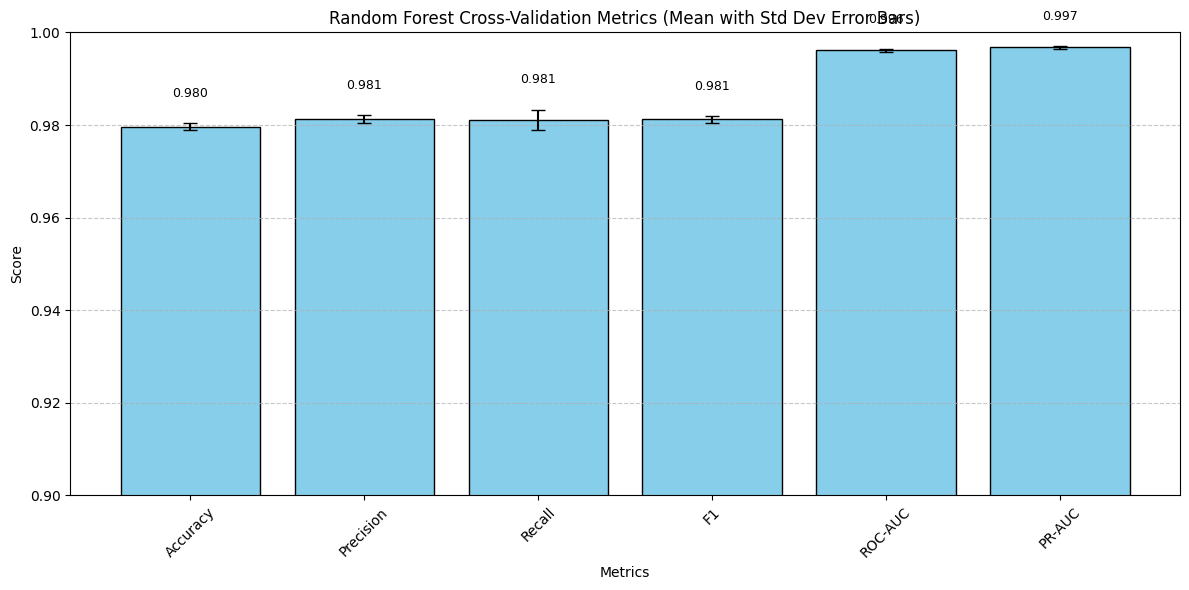

In [42]:
fig, ax = plt.subplots(figsize=(12, 6))

metrics = rf_cv_summary.index
mean_values = rf_cv_summary['Mean']
std_values = rf_cv_summary['Std']

ax.bar(metrics, mean_values, yerr=std_values, capsize=5, color='skyblue', edgecolor='black')

ax.set_title('Random Forest Cross-Validation Metrics (Mean with Std Dev Error Bars)')
ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0.9, 1.0) # Set y-axis limits to better visualize differences in high-scoring metrics
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of each bar
for i, mean in enumerate(mean_values):
    ax.text(i, mean + std_values[i] + 0.005, f'{mean:.3f}', ha='center', va='bottom', color='black', fontsize=9)

plt.tight_layout()
plt.show()

***XGBoost***

In [43]:
from xgboost import XGBClassifier

In [44]:
# XGBoost Pipeline

xgb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

In [45]:
# XGBoost Cross Validation

xgb_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train), 1
):

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Train
    xgb_pipeline.fit(X_fold_train, y_fold_train)

    # Predictions
    y_pred = xgb_pipeline.predict(X_fold_val)
    y_prob = xgb_pipeline.predict_proba(X_fold_val)[:, 1]

    # Metrics
    metrics = {
        "Fold": fold,
        "Accuracy": accuracy_score(y_fold_val, y_pred),
        "Precision": precision_score(y_fold_val, y_pred),
        "Recall": recall_score(y_fold_val, y_pred),
        "F1": f1_score(y_fold_val, y_pred),
        "ROC-AUC": roc_auc_score(y_fold_val, y_prob),
        "PR-AUC": average_precision_score(y_fold_val, y_prob)
    }

    xgb_cv_results.append(metrics)

xgb_cv_results_df = pd.DataFrame(xgb_cv_results)

xgb_cv_results_df

,Fold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,1,0.980475,0.984664,0.979270,0.981960,0.997251,0.998020
1,2,0.981298,0.986829,0.978596,0.982695,0.996990,0.997950
2,3,0.981161,0.984519,0.980703,0.982607,0.997582,0.998243
3,4,0.979880,0.985224,0.977587,0.981391,0.997645,0.998226
4,5,0.981708,0.985109,0.981124,0.983112,0.997323,0.998102


In [46]:
path = '/content/drive/MyDrive/Datasets/xgb_cv_results.csv'
xgb_cv_results_df.to_csv(path, index=False)

In [47]:
xgb_cv_summary = pd.DataFrame({
    "Mean" : xgb_cv_results_df.drop(columns="Fold").mean(),
    "Std" : xgb_cv_results_df.drop(columns="Fold").std()
})

xgb_cv_summary

,Mean,Std
Accuracy,0.980904,0.000725
Precision,0.985269,0.000920
Recall,0.979456,0.001467
F1,0.982353,0.000678
ROC-AUC,0.997358,0.000265
PR-AUC,0.998108,0.000127


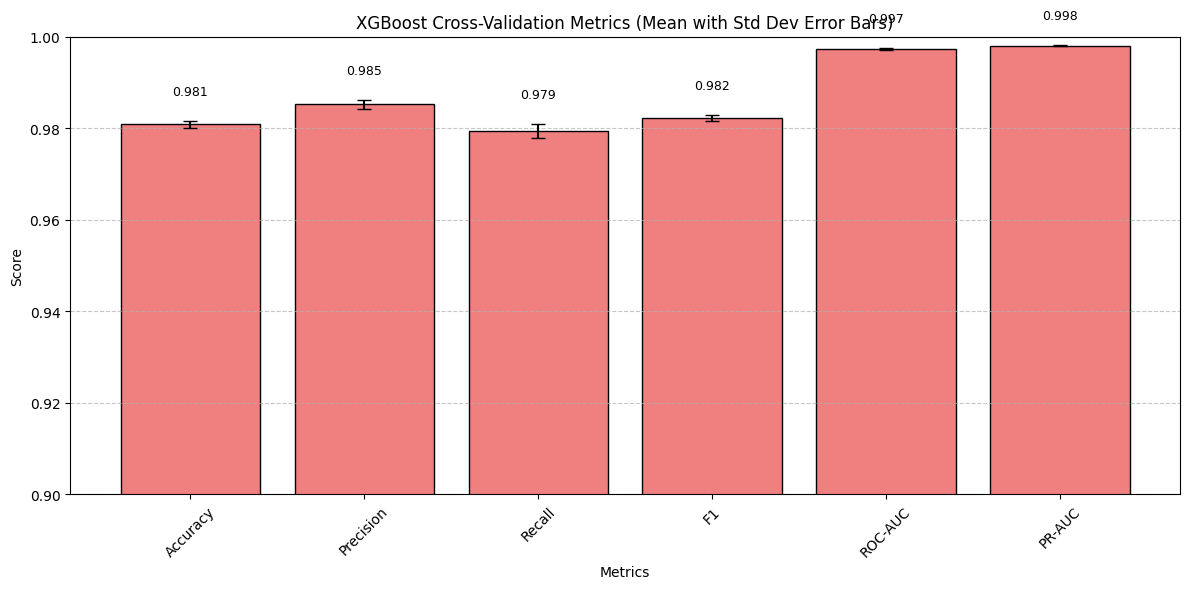

In [48]:
fig, ax = plt.subplots(figsize=(12, 6))

metrics = xgb_cv_summary.index
mean_values = xgb_cv_summary['Mean']
std_values = xgb_cv_summary['Std']

ax.bar(metrics, mean_values, yerr=std_values, capsize=5, color='lightcoral', edgecolor='black')

ax.set_title('XGBoost Cross-Validation Metrics (Mean with Std Dev Error Bars)')
ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0.9, 1.0) # Set y-axis limits to better visualize differences in high-scoring metrics
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of each bar
for i, mean in enumerate(mean_values):
    ax.text(i, mean + std_values[i] + 0.005, f'{mean:.3f}', ha='center', va='bottom', color='black', fontsize=9)

plt.tight_layout()
plt.show()

***LightGBM***

In [49]:
from lightgbm import LGBMClassifier

In [50]:
lgbm_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    ))
])

In [51]:
lgbm_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train), 1
):

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Train
    lgbm_pipeline.fit(X_fold_train, y_fold_train)

    # Predictions
    y_pred = lgbm_pipeline.predict(X_fold_val)
    y_prob = lgbm_pipeline.predict_proba(X_fold_val)[:, 1]

    # Metrics
    metrics = {
        "Fold": fold,
        "Accuracy": accuracy_score(y_fold_val, y_pred),
        "Precision": precision_score(y_fold_val, y_pred),
        "Recall": recall_score(y_fold_val, y_pred),
        "F1": f1_score(y_fold_val, y_pred),
        "ROC-AUC": roc_auc_score(y_fold_val, y_prob),
        "PR-AUC": average_precision_score(y_fold_val, y_prob)
    }

    lgbm_cv_results.append(metrics)

lgbm_cv_results_df = pd.DataFrame(lgbm_cv_results)

lgbm_cv_results_df

,Fold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,1,0.982075,0.985283,0.981630,0.983453,0.997561,0.998203
1,2,0.980886,0.986240,0.978428,0.982318,0.997142,0.998039
2,3,0.982121,0.985448,0.981545,0.983493,0.997755,0.998366
3,4,0.981709,0.987088,0.979103,0.983080,0.997736,0.998302
4,5,0.982440,0.985621,0.981967,0.983791,0.997519,0.998252


In [52]:
path = '/content/drive/MyDrive/Datasets/lgbm_cv_results.csv'
lgbm_cv_results_df.to_csv(path, index=False)

In [53]:
lgbm_cv_summary = pd.DataFrame({
    "Mean": lgbm_cv_results_df.drop(columns="Fold").mean(),
    "Std": lgbm_cv_results_df.drop(columns="Fold").std()
})
lgbm_cv_summary

,Mean,Std
Accuracy,0.981846,0.000596
Precision,0.985936,0.000739
Recall,0.980535,0.001640
F1,0.983227,0.000567
ROC-AUC,0.997543,0.000247
PR-AUC,0.998232,0.000124


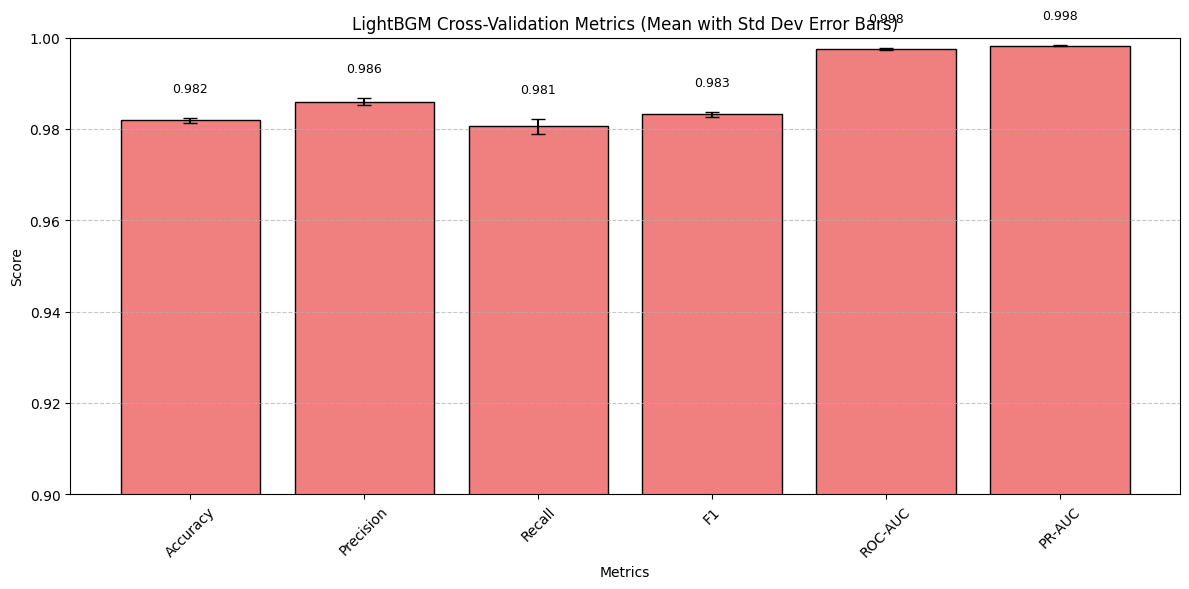

In [54]:
fig, ax = plt.subplots(figsize=(12, 6))

metrics = lgbm_cv_summary.index
mean_values = lgbm_cv_summary['Mean']
std_values = lgbm_cv_summary['Std']

ax.bar(metrics, mean_values, yerr=std_values, capsize=5, color='lightcoral', edgecolor='black')

ax.set_title('LightBGM Cross-Validation Metrics (Mean with Std Dev Error Bars)')
ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0.9, 1.0) # Set y-axis limits to better visualize differences in high-scoring metrics
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of each bar
for i, mean in enumerate(mean_values):
    ax.text(i, mean + std_values[i] + 0.005, f'{mean:.3f}', ha='center', va='bottom', color='black', fontsize=9)

plt.tight_layout()
plt.show()

***Logistic Regressions***

In [55]:
from sklearn.linear_model import LogisticRegression

In [56]:
lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

In [57]:
# Logistic Regression Cross Validation


lr_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train), 1
):

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Train
    lr_pipeline.fit(X_fold_train, y_fold_train)

    # Predict
    y_pred = lr_pipeline.predict(X_fold_val)
    y_prob = lr_pipeline.predict_proba(X_fold_val)[:, 1]

    # Metrics
    metrics = {
        "Fold": fold,
        "Accuracy": accuracy_score(y_fold_val, y_pred),
        "Precision": precision_score(y_fold_val, y_pred),
        "Recall": recall_score(y_fold_val, y_pred),
        "F1": f1_score(y_fold_val, y_pred),
        "ROC-AUC": roc_auc_score(y_fold_val, y_prob),
        "PR-AUC": average_precision_score(y_fold_val, y_prob)
    }

    lr_cv_results.append(metrics)

lr_cv_results_df = pd.DataFrame(lr_cv_results)

lr_cv_results_df

,Fold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,1,0.872697,0.934718,0.822870,0.875235,0.916677,0.939517
1,2,0.876949,0.943628,0.822365,0.878833,0.918488,0.944095
2,3,0.879235,0.947951,0.822617,0.880848,0.920842,0.946338
3,4,0.877818,0.942371,0.825329,0.879975,0.918878,0.946204
4,5,0.874017,0.934401,0.825819,0.876761,0.919027,0.941715


In [58]:
path = '/content/drive/MyDrive/Datasets/lr_cv_results.csv'
lr_cv_results_df.to_csv(path, index=False)

In [59]:
lr_cv_summary = pd.DataFrame({
    "Mean": lr_cv_results_df.drop(columns="Fold").mean(),
    "Std": lr_cv_results_df.drop(columns="Fold").std()
})
lr_cv_summary

,Mean,Std
Accuracy,0.876143,0.002712
Precision,0.940614,0.005903
Recall,0.823800,0.001639
F1,0.878331,0.002310
ROC-AUC,0.918783,0.001486
PR-AUC,0.943574,0.002947


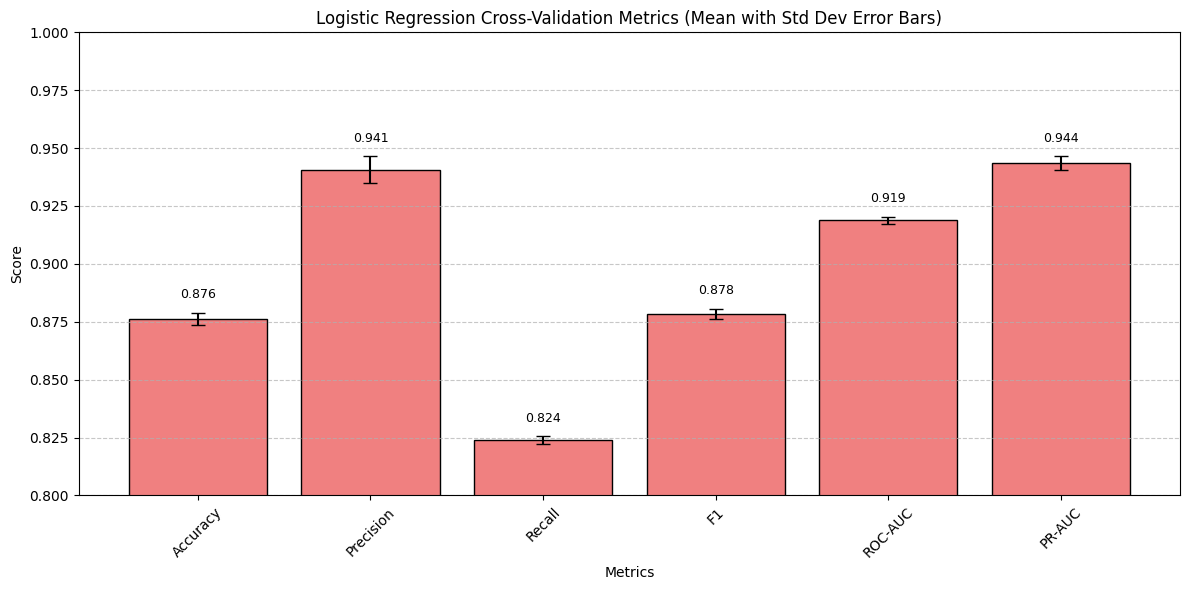

In [60]:
fig, ax = plt.subplots(figsize=(12, 6))

metrics = lr_cv_summary.index
mean_values = lr_cv_summary['Mean']
std_values = lr_cv_summary['Std']

ax.bar(metrics, mean_values, yerr=std_values, capsize=5, color='lightcoral', edgecolor='black')

ax.set_title('Logistic Regression Cross-Validation Metrics (Mean with Std Dev Error Bars)')
ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0.8, 1.0) # Set y-axis limits to better visualize differences in high-scoring metrics
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of each bar
for i, mean in enumerate(mean_values):
    ax.text(i, mean + std_values[i] + 0.005, f'{mean:.3f}', ha='center', va='bottom', color='black', fontsize=9)

plt.tight_layout()
plt.show()

***KNN***

In [61]:
from sklearn.neighbors import KNeighborsClassifier

In [62]:
knn_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", KNeighborsClassifier())
])

In [63]:
# KNN Cross Validation


knn_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train), 1
):

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Train
    knn_pipeline.fit(X_fold_train, y_fold_train)

    # Predict
    y_pred = knn_pipeline.predict(X_fold_val)
    y_prob = knn_pipeline.predict_proba(X_fold_val)[:, 1]

    # Metrics
    metrics = {
        "Fold": fold,
        "Accuracy": accuracy_score(y_fold_val, y_pred),
        "Precision": precision_score(y_fold_val, y_pred),
        "Recall": recall_score(y_fold_val, y_pred),
        "F1": f1_score(y_fold_val, y_pred),
        "ROC-AUC": roc_auc_score(y_fold_val, y_prob),
        "PR-AUC": average_precision_score(y_fold_val, y_prob)
    }

    knn_cv_results.append(metrics)

knn_cv_results_df = pd.DataFrame(knn_cv_results)

knn_cv_results_df

,Fold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,1,0.974439,0.978180,0.974636,0.976405,0.989118,0.986092
1,2,0.973936,0.979621,0.972192,0.975892,0.989841,0.987991
2,3,0.974759,0.977950,0.975478,0.976713,0.989800,0.987402
3,4,0.974347,0.978745,0.973879,0.976306,0.988897,0.986631
4,5,0.976861,0.978277,0.979102,0.978689,0.990590,0.988705


In [64]:
path = '/content/drive/MyDrive/Datasets/knn_cv_results.csv'
knn_cv_results_df.to_csv(path, index=False)

In [65]:
knn_cv_summary = pd.DataFrame({
    "Mean": knn_cv_results_df.drop(columns="Fold").mean(),
    "Std": knn_cv_results_df.drop(columns="Fold").std()
})
knn_cv_summary

,Mean,Std
Accuracy,0.974868,0.001152
Precision,0.978555,0.000663
Recall,0.975057,0.002565
F1,0.976801,0.001096
ROC-AUC,0.989649,0.000669
PR-AUC,0.987364,0.001043


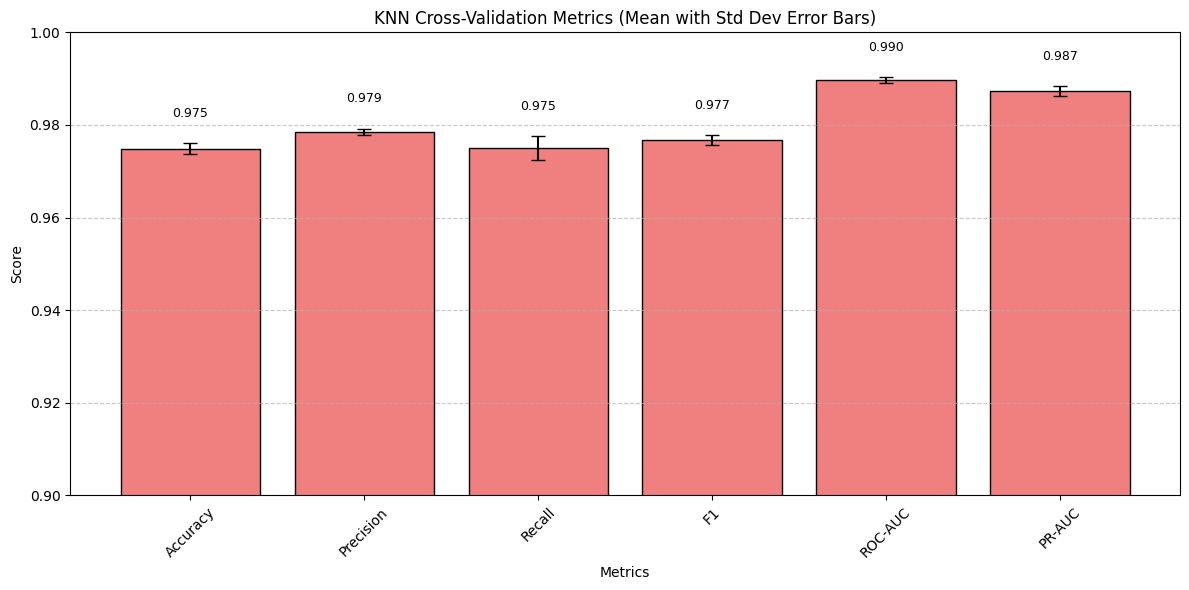

In [66]:
fig, ax = plt.subplots(figsize=(12, 6))

metrics = knn_cv_summary.index
mean_values = knn_cv_summary['Mean']
std_values = knn_cv_summary['Std']

ax.bar(metrics, mean_values, yerr=std_values, capsize=5, color='lightcoral', edgecolor='black')

ax.set_title('KNN Cross-Validation Metrics (Mean with Std Dev Error Bars)')
ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0.9, 1.0) # Set y-axis limits to better visualize differences in high-scoring metrics
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of each bar
for i, mean in enumerate(mean_values):
    ax.text(i, mean + std_values[i] + 0.005, f'{mean:.3f}', ha='center', va='bottom', color='black', fontsize=9)

plt.tight_layout()
plt.show()

***Decision Tree***

In [67]:
from sklearn.tree import DecisionTreeClassifier

In [68]:
dt_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

In [69]:
dt_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train), 1
):

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Train
    dt_pipeline.fit(X_fold_train, y_fold_train)

    # Predict
    y_pred = dt_pipeline.predict(X_fold_val)
    y_prob = dt_pipeline.predict_proba(X_fold_val)[:, 1]

    # Metrics
    metrics = {
        "Fold": fold,
        "Accuracy": accuracy_score(y_fold_val, y_pred),
        "Precision": precision_score(y_fold_val, y_pred),
        "Recall": recall_score(y_fold_val, y_pred),
        "F1": f1_score(y_fold_val, y_pred),
        "ROC-AUC": roc_auc_score(y_fold_val, y_prob),
        "PR-AUC": average_precision_score(y_fold_val, y_prob)
    }

    dt_cv_results.append(metrics)

dt_cv_results_df = pd.DataFrame(dt_cv_results)

dt_cv_results_df

,Fold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,1,0.976176,0.978573,0.977501,0.978036,0.976053,0.968764
1,2,0.976908,0.981196,0.976152,0.978668,0.976978,0.970737
2,3,0.977502,0.979189,0.979355,0.979272,0.977330,0.970177
3,4,0.976314,0.977533,0.978851,0.978191,0.976076,0.968336
4,5,0.975626,0.974941,0.980281,0.977604,0.975192,0.966417


In [70]:
path = '/content/drive/MyDrive/Datasets/dt_cv_results.csv'
dt_cv_results_df.to_csv(path, index=False)

In [71]:
dt_cv_summary = pd.DataFrame({
    "Mean": dt_cv_results_df.drop(columns="Fold").mean(),
    "Std": dt_cv_results_df.drop(columns="Fold").std()
})
dt_cv_summary

,Mean,Std
Accuracy,0.976505,0.000720
Precision,0.978286,0.002298
Recall,0.978428,0.001621
F1,0.978354,0.000639
ROC-AUC,0.976326,0.000845
PR-AUC,0.968886,0.001696


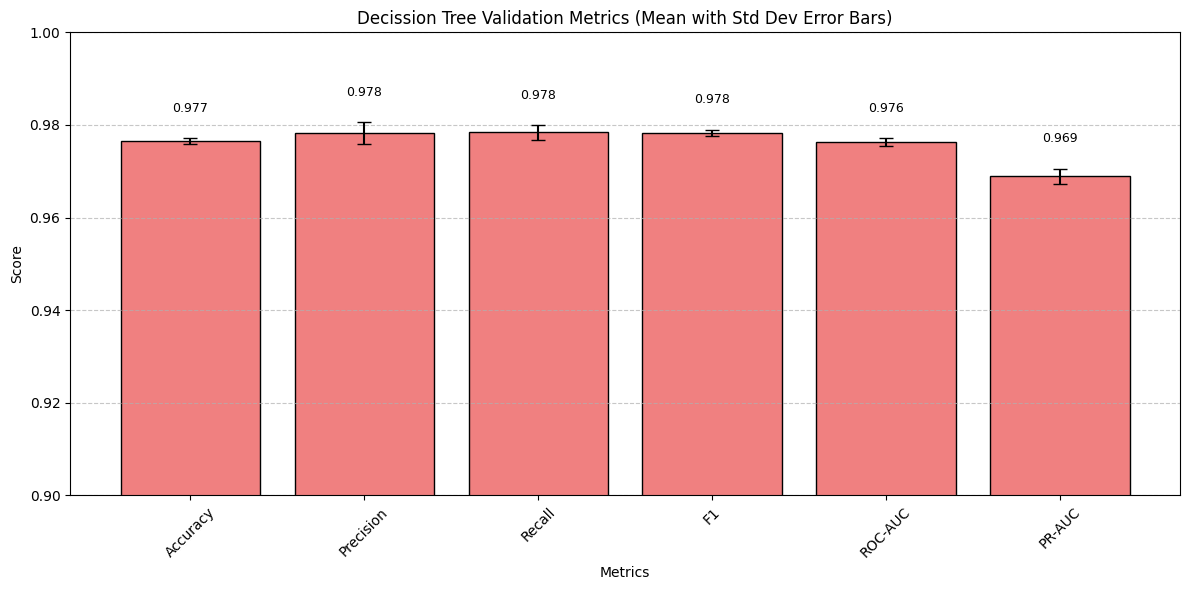

In [72]:
fig, ax = plt.subplots(figsize=(12, 6))

metrics = dt_cv_summary.index
mean_values = dt_cv_summary['Mean']
std_values = dt_cv_summary['Std']

ax.bar(metrics, mean_values, yerr=std_values, capsize=5, color='lightcoral', edgecolor='black')

ax.set_title('Decission Tree Validation Metrics (Mean with Std Dev Error Bars)')
ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0.9, 1.0) # Set y-axis limits to better visualize differences in high-scoring metrics
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of each bar
for i, mean in enumerate(mean_values):
    ax.text(i, mean + std_values[i] + 0.005, f'{mean:.3f}', ha='center', va='bottom', color='black', fontsize=9)

plt.tight_layout()
plt.show()

## **ML CV Comparison**

In [73]:
ml_cv_summary = pd.DataFrame({
    "Random Forest": rf_cv_summary["Mean"],
    "XGBoost": xgb_cv_summary["Mean"],
    "LightGBM": lgbm_cv_summary["Mean"],
    "Logistic Regression": lr_cv_summary["Mean"],
    "KNN": knn_cv_summary["Mean"],
    "Decision Tree": dt_cv_summary["Mean"]
}).T

ml_cv_summary

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Random Forest,0.979661,0.981342,0.981175,0.981257,0.996121,0.996776
XGBoost,0.980904,0.985269,0.979456,0.982353,0.997358,0.998108
LightGBM,0.981846,0.985936,0.980535,0.983227,0.997543,0.998232
Logistic Regression,0.876143,0.940614,0.823800,0.878331,0.918783,0.943574
KNN,0.974868,0.978555,0.975057,0.976801,0.989649,0.987364
Decision Tree,0.976505,0.978286,0.978428,0.978354,0.976326,0.968886


In [74]:
ml_cv_std = pd.DataFrame({
    "Random Forest": rf_cv_summary["Std"],
    "XGBoost": xgb_cv_summary["Std"],
    "LightGBM": lgbm_cv_summary["Std"],
    "Logistic Regression": lr_cv_summary["Std"],
    "KNN": knn_cv_summary["Std"],
    "Decision Tree": dt_cv_summary["Std"]
}).T

ml_cv_std

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Random Forest,0.000804,0.000871,0.002166,0.000766,0.000263,0.000263
XGBoost,0.000725,0.000920,0.001467,0.000678,0.000265,0.000127
LightGBM,0.000596,0.000739,0.001640,0.000567,0.000247,0.000124
Logistic Regression,0.002712,0.005903,0.001639,0.002310,0.001486,0.002947
KNN,0.001152,0.000663,0.002565,0.001096,0.000669,0.001043
Decision Tree,0.000720,0.002298,0.001621,0.000639,0.000845,0.001696


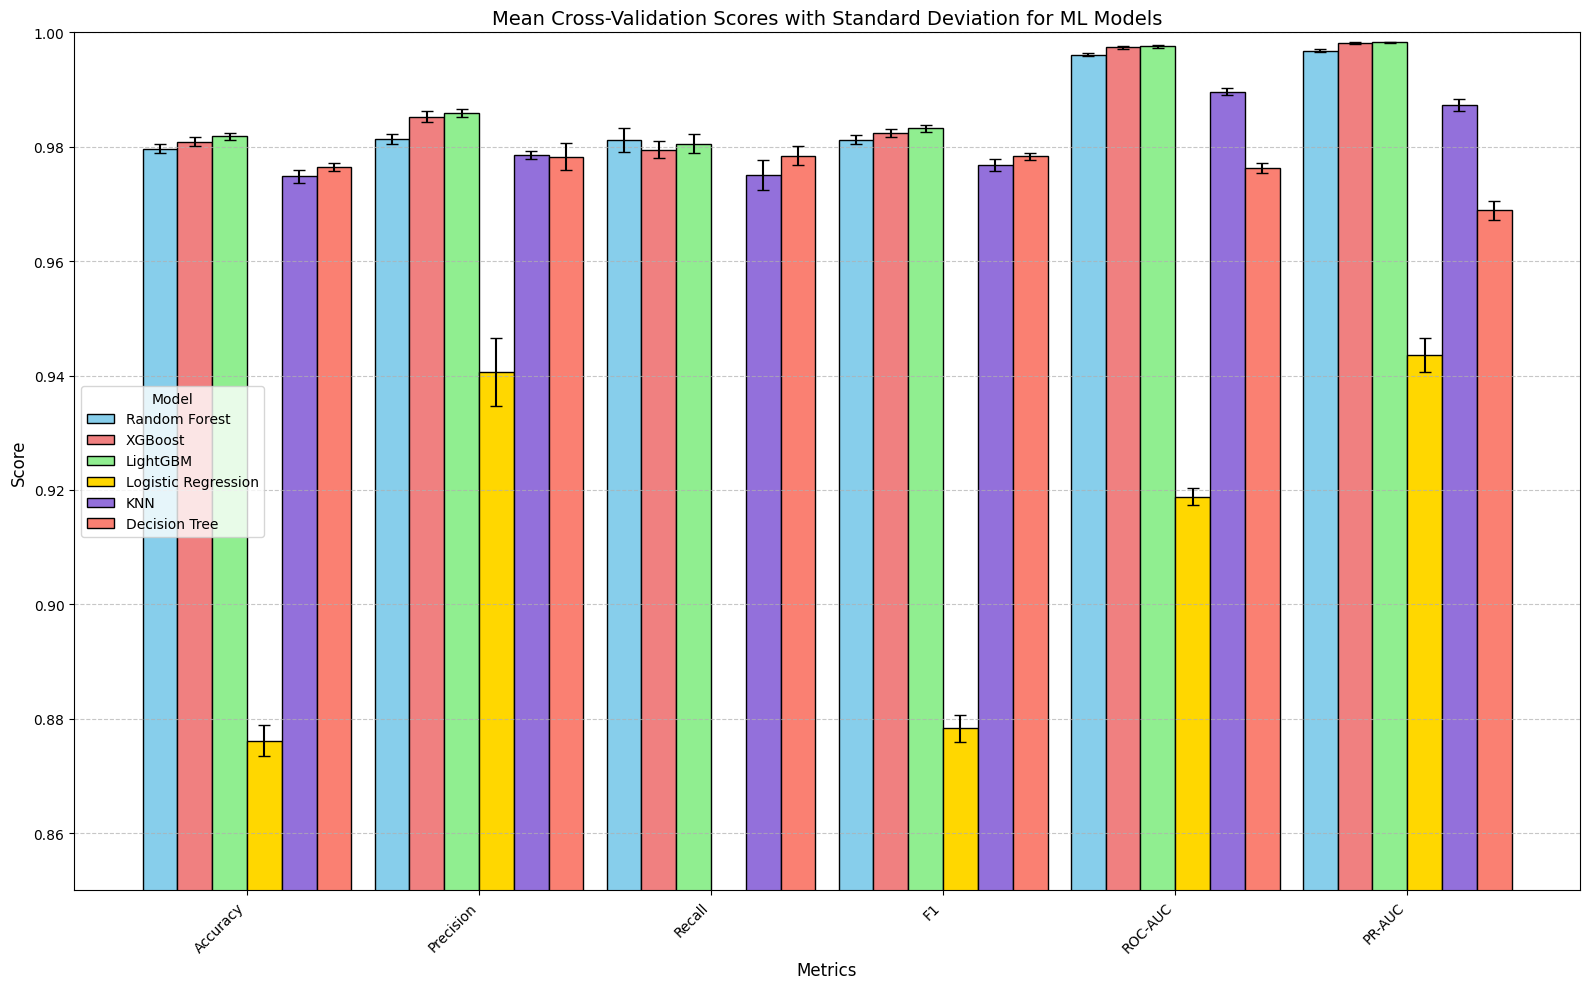

In [75]:
fig, ax = plt.subplots(figsize=(16, 10))

metrics = ml_cv_summary.columns
models = ml_cv_summary.index

bar_width = 0.15 # Adjusted bar width for more models
index = np.arange(len(metrics))

colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'mediumpurple', 'salmon'] # Extended color list

for i, model in enumerate(models):
    means = ml_cv_summary.loc[model]
    stds = ml_cv_std.loc[model]
    ax.bar(index + i * bar_width, means, bar_width, yerr=stds, capsize=4, label=model, color=colors[i], edgecolor='black') # Adjusted capsize for better visibility

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Mean Cross-Validation Scores with Standard Deviation for ML Models', fontsize=14)
ax.set_xticks(index + bar_width * (len(models) - 1) / 2)
ax.set_xticklabels(metrics, rotation=45, ha='right', fontsize=10)
ax.set_ylim(0.85, 1.0) # Adjusted y-axis limits to better show all models
ax.legend(title='Model', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

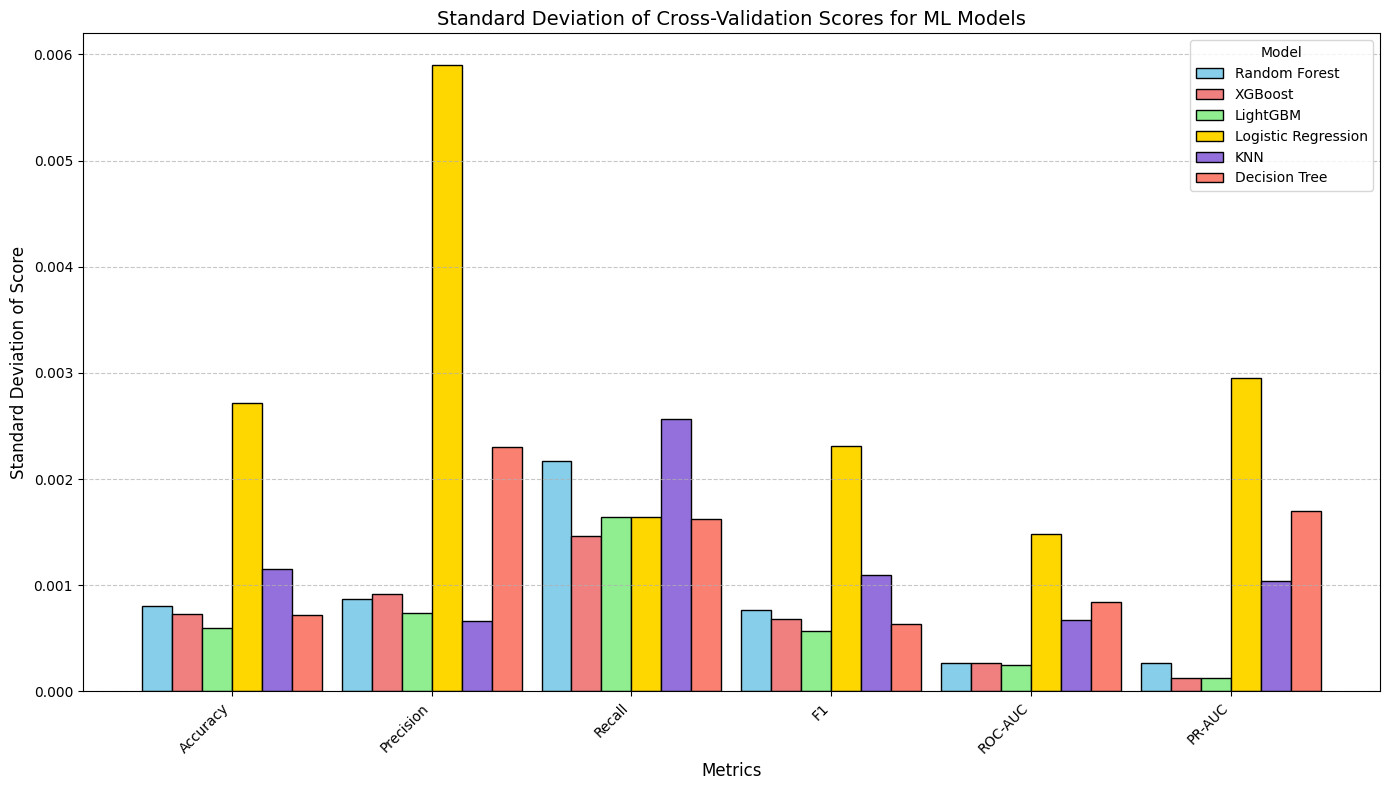

In [76]:
fig, ax = plt.subplots(figsize=(14, 8))

metrics = ml_cv_std.columns
models = ml_cv_std.index

bar_width = 0.15 # Adjusted bar width for more models
index = np.arange(len(metrics))

colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'mediumpurple', 'salmon'] # Extended color list

for i, model in enumerate(models):
    stds = ml_cv_std.loc[model]
    ax.bar(index + i * bar_width, stds, bar_width, label=model, color=colors[i], edgecolor='black')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Standard Deviation of Score', fontsize=12)
ax.set_title('Standard Deviation of Cross-Validation Scores for ML Models', fontsize=14)
ax.set_xticks(index + bar_width * (len(models) - 1) / 2)
ax.set_xticklabels(metrics, rotation=45, ha='right', fontsize=10)
ax.legend(title='Model', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# **DL Model**

***MLP***

In [77]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [78]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

In [79]:
def train_mlp(
    model,
    X_train_fold,
    y_train_fold,
    X_val_fold,
    y_val_fold,
    epochs=30,
    batch_size=512,
    learning_rate=0.001,
    patience=5
):

    # Convert to tensors
    X_train_tensor = torch.tensor(
        X_train_fold,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train_fold,
        dtype=torch.float32
    ).reshape(-1, 1)

    X_val_tensor = torch.tensor(
        X_val_fold,
        dtype=torch.float32
    ).to(device)

    y_val_tensor = torch.tensor(
        y_val_fold,
        dtype=torch.float32
    ).reshape(-1, 1).to(device)

    # Dataset and DataLoader
    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # Loss and optimizer
    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    model.to(device)

    best_val_loss = float("inf")
    patience_counter = 0

    best_state = None

    history = {
        "train_loss": [],
        "val_loss": []
    }

    # Training loop
    for epoch in range(epochs):

        model.train()

        running_loss = 0.0

        for batch_X, batch_y in train_loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()

            outputs = model(batch_X)

            loss = criterion(
                outputs,
                batch_y
            )

            loss.backward()

            optimizer.step()

            running_loss += loss.item() * len(batch_X)

        train_loss = (
            running_loss /
            len(train_dataset)
        )

        # Validation
        model.eval()

        with torch.no_grad():

            val_outputs = model(
                X_val_tensor
            )

            val_loss = criterion(
                val_outputs,
                y_val_tensor
            ).item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # Early stopping
        if val_loss < best_val_loss:

            best_val_loss = val_loss
            patience_counter = 0

            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        else:

            patience_counter += 1

            if patience_counter >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

In [80]:
# ============================================
# 16.4 MLP — 5-Fold Cross-Validation
# ============================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import time

mlp_cv_results = []

mlp_histories = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train), 1
):

    print(f"\n========== Fold {fold} ==========")

    # ----------------------------------------
    # Split fold
    # ----------------------------------------

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # ----------------------------------------
    # Imputation
    # ----------------------------------------

    imputer = SimpleImputer(
        strategy="median"
    )

    X_fold_train_imp = imputer.fit_transform(
        X_fold_train
    )

    X_fold_val_imp = imputer.transform(
        X_fold_val
    )

    # ----------------------------------------
    # Standardization
    # ----------------------------------------

    scaler = StandardScaler()

    X_fold_train_scaled = scaler.fit_transform(
        X_fold_train_imp
    )

    X_fold_val_scaled = scaler.transform(
        X_fold_val_imp
    )

    # ----------------------------------------
    # Create model
    # ----------------------------------------

    model = MLP(
        input_dim=X_fold_train_scaled.shape[1]
    )

    # ----------------------------------------
    # Train
    # ----------------------------------------

    start_time = time.time()

    model, history = train_mlp(
        model,
        X_fold_train_scaled,
        y_fold_train.to_numpy(),
        X_fold_val_scaled,
        y_fold_val.to_numpy(),
        epochs=30,
        batch_size=512,
        learning_rate=0.001,
        patience=5
    )

    training_time = time.time() - start_time

    mlp_histories.append(history)

    # ----------------------------------------
    # Validation prediction
    # ----------------------------------------

    model.eval()

    X_val_tensor = torch.tensor(
        X_fold_val_scaled,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        logits = model(
            X_val_tensor
        )

        probabilities = torch.sigmoid(
            logits
        ).cpu().numpy().ravel()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    # ----------------------------------------
    # Metrics
    # ----------------------------------------

    metrics = {
        "Fold": fold,

        "Accuracy": accuracy_score(
            y_fold_val,
            predictions
        ),

        "Precision": precision_score(
            y_fold_val,
            predictions
        ),

        "Recall": recall_score(
            y_fold_val,
            predictions
        ),

        "F1": f1_score(
            y_fold_val,
            predictions
        ),

        "ROC-AUC": roc_auc_score(
            y_fold_val,
            probabilities
        ),

        "PR-AUC": average_precision_score(
            y_fold_val,
            probabilities
        ),

        "Training_Time_sec": training_time
    }

    mlp_cv_results.append(metrics)

    print(
        f"Accuracy: {metrics['Accuracy']:.4f} | "
        f"Precision: {metrics['Precision']:.4f} | "
        f"Recall: {metrics['Recall']:.4f} | "
        f"F1: {metrics['F1']:.4f} | "
        f"ROC-AUC: {metrics['ROC-AUC']:.4f} | "
        f"Time: {training_time:.1f}s"
    )


========== Fold 1 ==========
Accuracy: 0.9698 | Precision: 0.9762 | Recall: 0.9679 | F1: 0.9720 | ROC-AUC: 0.9898 | Time: 32.8s

========== Fold 2 ==========
Accuracy: 0.9711 | Precision: 0.9824 | Recall: 0.9641 | F1: 0.9732 | ROC-AUC: 0.9892 | Time: 26.3s

========== Fold 3 ==========
Accuracy: 0.9720 | Precision: 0.9810 | Recall: 0.9671 | F1: 0.9740 | ROC-AUC: 0.9896 | Time: 29.9s

========== Fold 4 ==========
Accuracy: 0.9704 | Precision: 0.9809 | Recall: 0.9643 | F1: 0.9725 | ROC-AUC: 0.9900 | Time: 28.1s

========== Fold 5 ==========
Accuracy: 0.9712 | Precision: 0.9807 | Recall: 0.9660 | F1: 0.9733 | ROC-AUC: 0.9904 | Time: 26.4s


In [81]:
mlp_cv_results_df = pd.DataFrame(
    mlp_cv_results
)

mlp_cv_results_df

,Fold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Training_Time_sec
0,1,0.969775,0.976203,0.967894,0.972031,0.989821,0.993152,32.789429
1,2,0.971146,0.982397,0.964102,0.973164,0.989160,0.992900,26.293427
2,3,0.971969,0.981022,0.967051,0.973987,0.989616,0.993131,29.876654
3,4,0.970415,0.980886,0.964274,0.972509,0.990045,0.993335,28.112925
4,5,0.971191,0.980666,0.965956,0.973255,0.990375,0.993506,26.410354


In [82]:
mlp_cv_summary = pd.DataFrame({
    "Mean": mlp_cv_results_df.drop(
        columns="Fold"
    ).mean(),

    "Std": mlp_cv_results_df.drop(
        columns="Fold"
    ).std()
})

mlp_cv_summary

,Mean,Std
Accuracy,0.970899,0.000835
Precision,0.980235,0.002354
Recall,0.965855,0.001671
F1,0.972989,0.000749
ROC-AUC,0.989803,0.000456
PR-AUC,0.993205,0.000229
Training_Time_sec,28.696558,2.715079


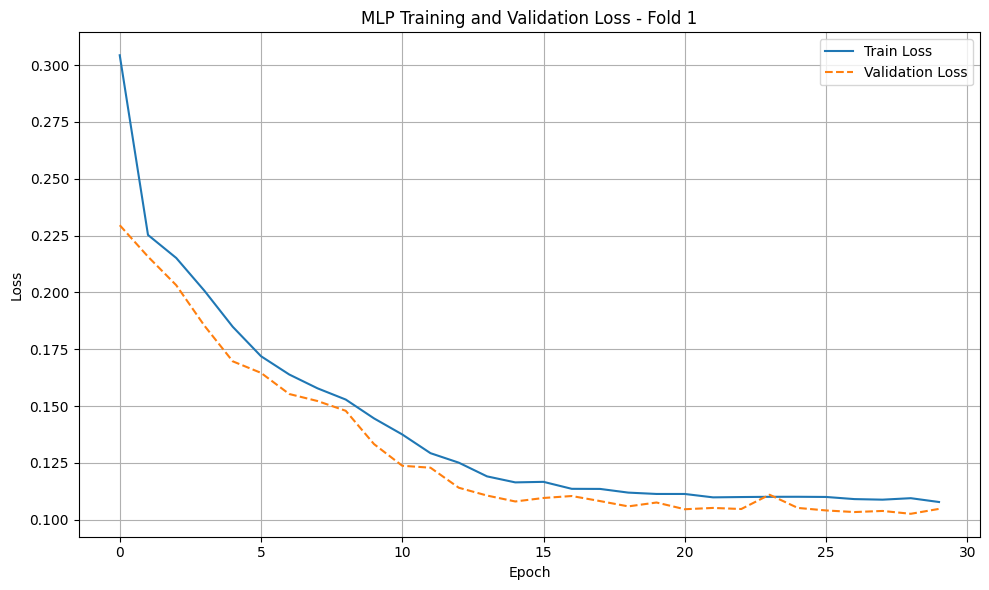

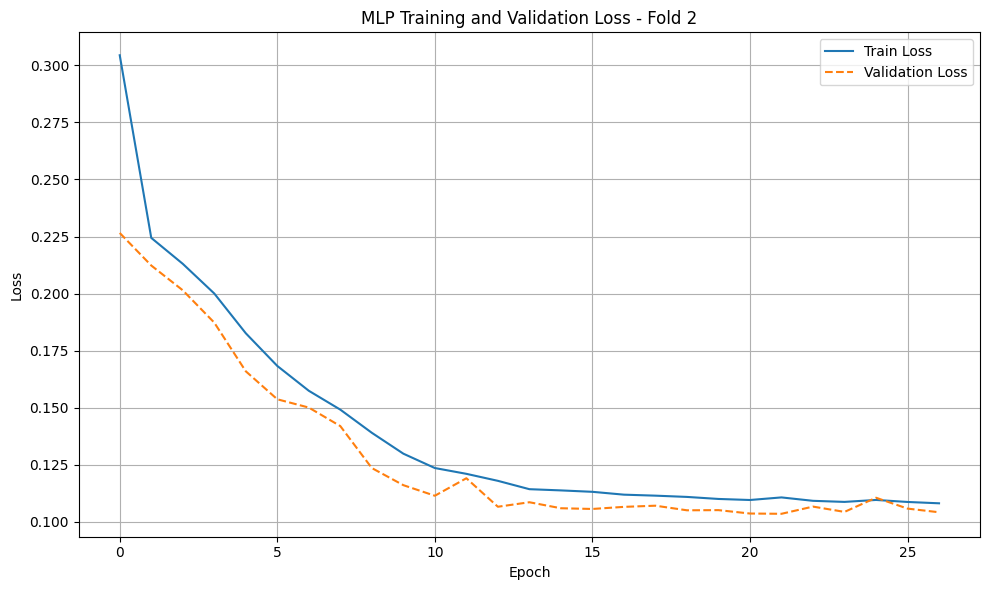

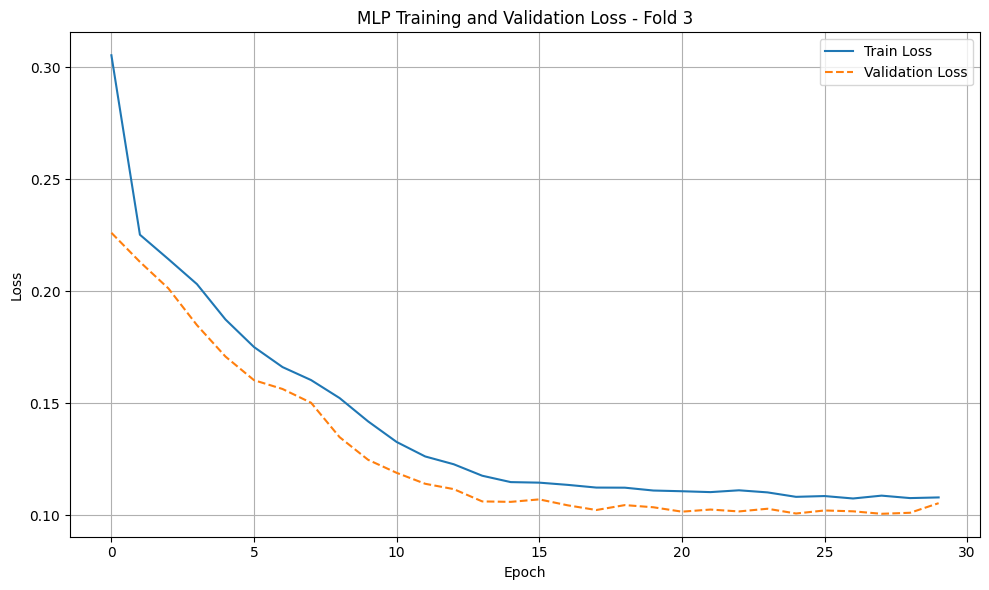

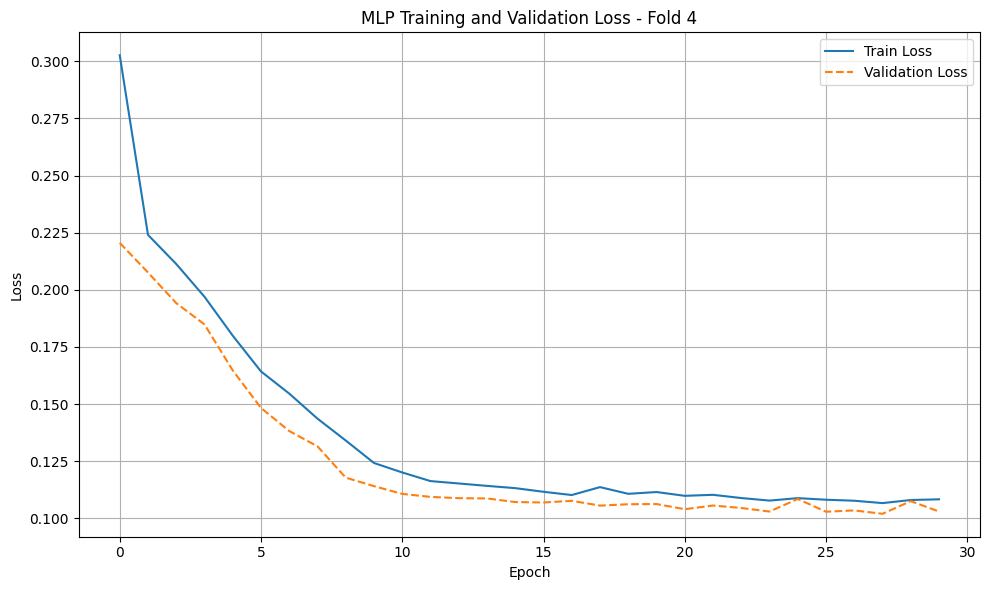

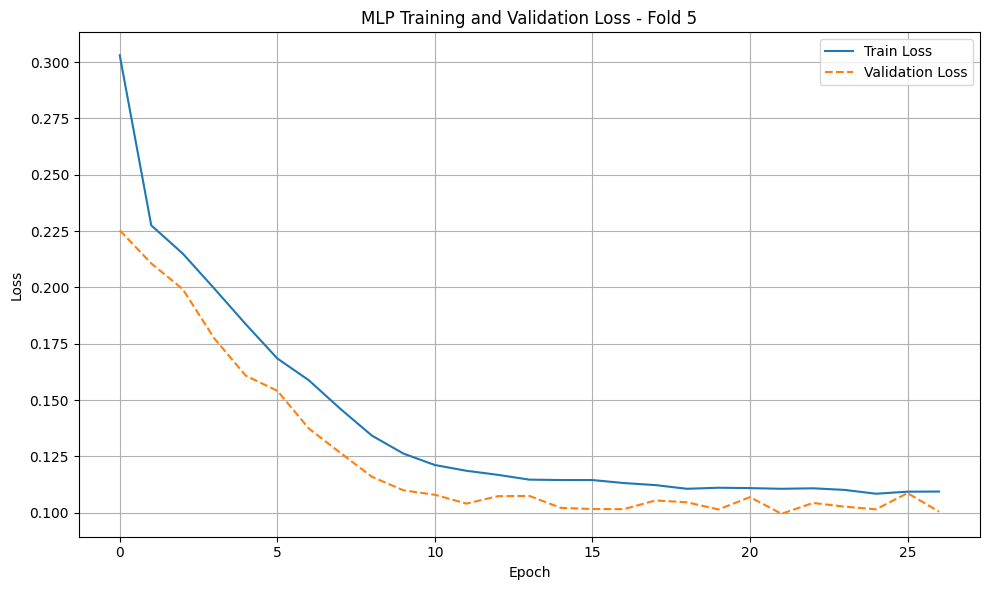

In [83]:
for i, history in enumerate(mlp_histories):
    plt.figure(figsize=(10, 6))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss', linestyle='--')
    plt.title(f'MLP Training and Validation Loss - Fold {i+1}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

***1D-CNN***

In [84]:
class CNN1D(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Dropout(0.30),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x

In [85]:
def train_cnn(
    model,
    X_train_fold,
    y_train_fold,
    X_val_fold,
    y_val_fold,
    epochs=30,
    batch_size=512,
    learning_rate=0.001,
    patience=5
):

    # Add channel dimension
    X_train_fold = X_train_fold[:, np.newaxis, :]
    X_val_fold = X_val_fold[:, np.newaxis, :]

    # Convert to tensors
    X_train_tensor = torch.tensor(
        X_train_fold,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train_fold,
        dtype=torch.float32
    ).reshape(-1, 1)

    X_val_tensor = torch.tensor(
        X_val_fold,
        dtype=torch.float32
    ).to(device)

    y_val_tensor = torch.tensor(
        y_val_fold,
        dtype=torch.float32
    ).reshape(-1, 1).to(device)

    # Dataset
    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    model.to(device)

    best_val_loss = float("inf")
    patience_counter = 0
    best_state = None

    history = {
        "train_loss": [],
        "val_loss": []
    }

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0

        for batch_X, batch_y in train_loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()

            outputs = model(batch_X)

            loss = criterion(
                outputs,
                batch_y
            )

            loss.backward()
            optimizer.step()

            running_loss += (
                loss.item() * len(batch_X)
            )

        train_loss = (
            running_loss /
            len(train_dataset)
        )

        # Validation
        model.eval()

        with torch.no_grad():

            val_outputs = model(
                X_val_tensor
            )

            val_loss = criterion(
                val_outputs,
                y_val_tensor
            ).item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # Early stopping
        if val_loss < best_val_loss:

            best_val_loss = val_loss
            patience_counter = 0

            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        else:

            patience_counter += 1

            if patience_counter >= patience:
                break

    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

In [86]:
cnn_cv_results = []
cnn_histories = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train), 1
):

    print(f"\n========== Fold {fold} ==========")

    # Fold data
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Imputation

    imputer = SimpleImputer(
        strategy="median"
    )

    X_fold_train_imp = imputer.fit_transform(
        X_fold_train
    )

    X_fold_val_imp = imputer.transform(
        X_fold_val
    )

    # Standardization

    scaler = StandardScaler()

    X_fold_train_scaled = scaler.fit_transform(
        X_fold_train_imp
    )

    X_fold_val_scaled = scaler.transform(
        X_fold_val_imp
    )

    # Create CNN

    model = CNN1D(
        input_dim=X_fold_train_scaled.shape[1]
    )

    # Train

    start_time = time.time()

    model, history = train_cnn(
        model,
        X_fold_train_scaled,
        y_fold_train.to_numpy(),
        X_fold_val_scaled,
        y_fold_val.to_numpy(),
        epochs=30,
        batch_size=512,
        learning_rate=0.001,
        patience=5
    )

    training_time = time.time() - start_time

    cnn_histories.append(history)

    # Validation prediction

    model.eval()

    X_val_tensor = torch.tensor(
        X_fold_val_scaled[:, np.newaxis, :],
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        logits = model(X_val_tensor)

        probabilities = torch.sigmoid(
            logits
        ).cpu().numpy().ravel()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    # Metrics

    metrics = {
        "Fold": fold,

        "Accuracy": accuracy_score(
            y_fold_val,
            predictions
        ),

        "Precision": precision_score(
            y_fold_val,
            predictions
        ),

        "Recall": recall_score(
            y_fold_val,
            predictions
        ),

        "F1": f1_score(
            y_fold_val,
            predictions
        ),

        "ROC-AUC": roc_auc_score(
            y_fold_val,
            probabilities
        ),

        "PR-AUC": average_precision_score(
            y_fold_val,
            probabilities
        ),

        "Training_Time_sec": training_time
    }

    cnn_cv_results.append(metrics)

    print(
        f"Time: {training_time:.1f}s"
    )


========== Fold 1 ==========
Time: 173.6s

========== Fold 2 ==========
Time: 175.6s

========== Fold 3 ==========
Time: 171.4s

========== Fold 4 ==========
Time: 175.6s

========== Fold 5 ==========
Time: 173.9s


In [87]:
cnn_cv_results_df = pd.DataFrame(
    cnn_cv_results
)

cnn_cv_results_df

,Fold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Training_Time_sec
0,1,0.919018,0.980304,0.868206,0.920856,0.962183,0.975667,173.569103
1,2,0.920252,0.981452,0.869470,0.922073,0.962193,0.975723,175.602458
2,3,0.919841,0.981803,0.868374,0.921612,0.957876,0.973038,171.415278
3,4,0.922081,0.983172,0.871335,0.923881,0.960412,0.974315,175.614636
4,5,0.922352,0.981989,0.872925,0.924251,0.962290,0.975996,173.932151


In [88]:
cnn_cv_summary = pd.DataFrame({
    "Mean": cnn_cv_results_df.drop(
        columns="Fold"
    ).mean(),

    "Std": cnn_cv_results_df.drop(
        columns="Fold"
    ).std()
})

cnn_cv_summary

,Mean,Std
Accuracy,0.920709,0.001450
Precision,0.981744,0.001032
Recall,0.870062,0.002028
F1,0.922535,0.001470
ROC-AUC,0.960991,0.001910
PR-AUC,0.974948,0.001252
Training_Time_sec,174.026725,1.735109


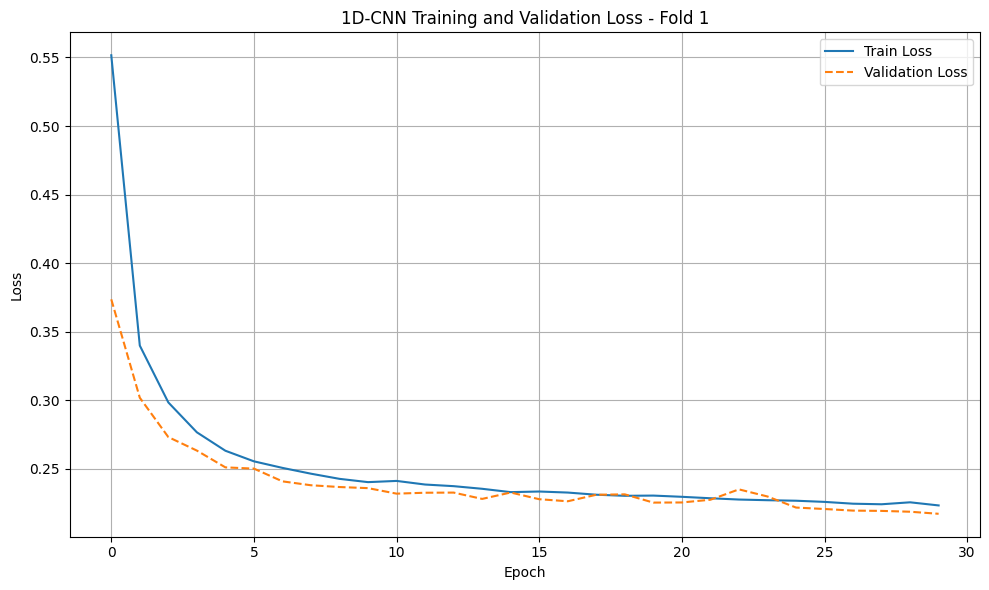

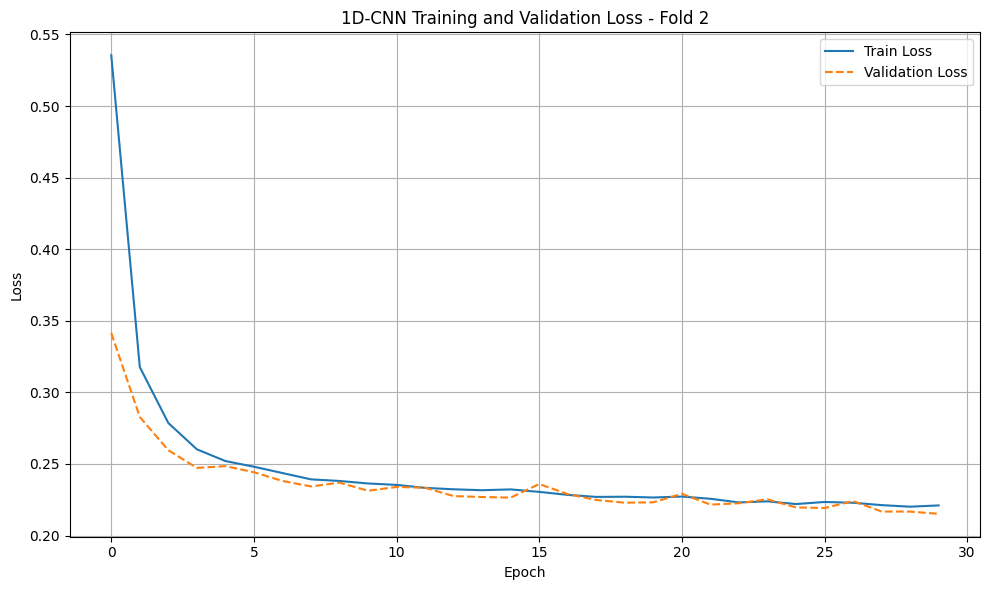

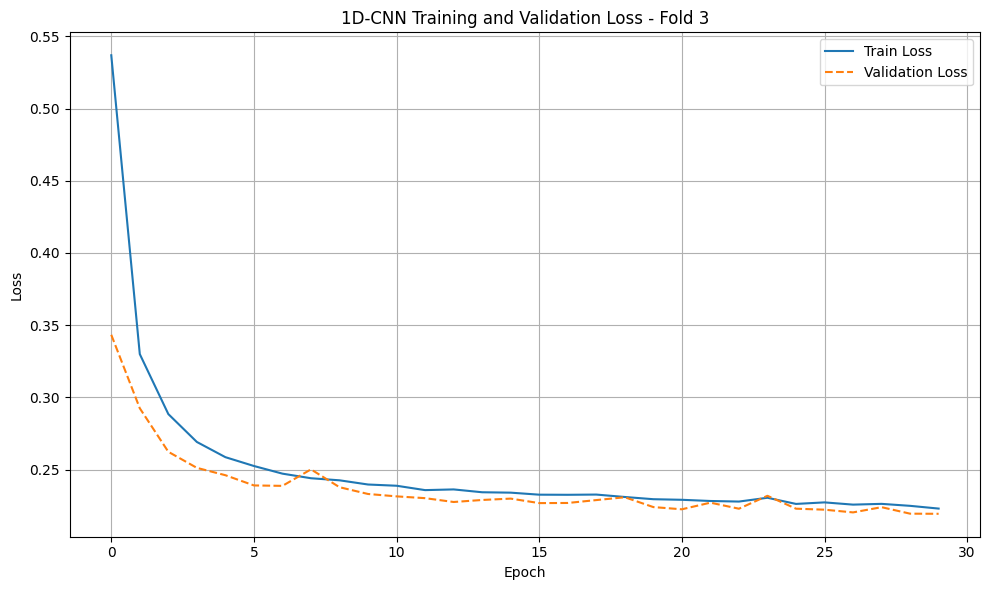

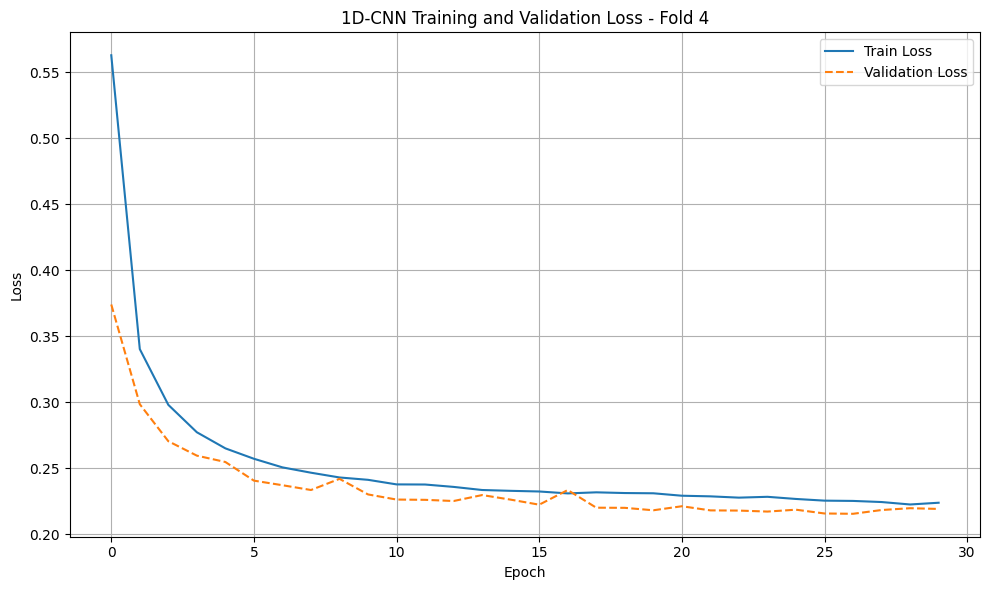

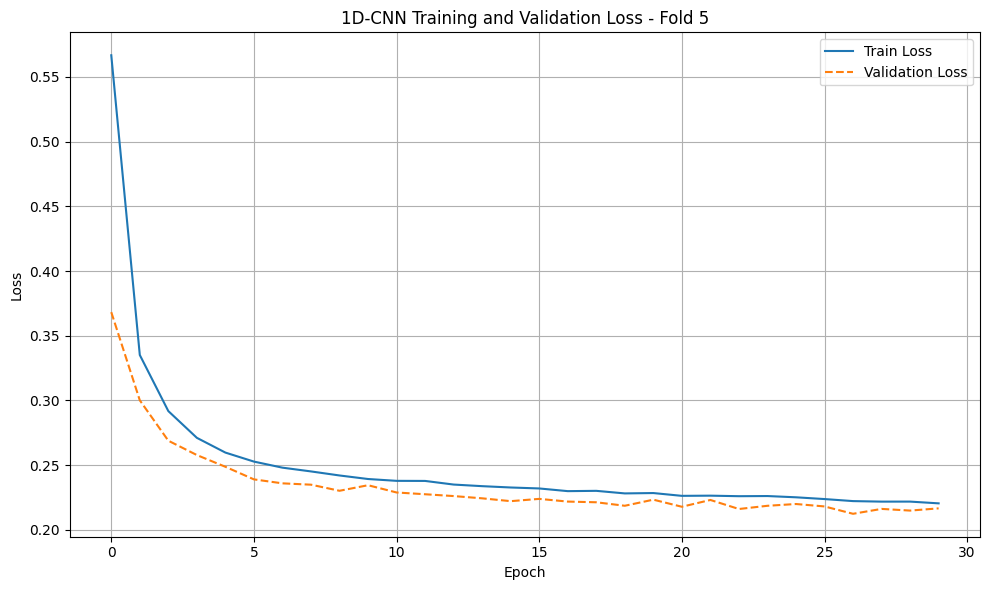

In [89]:
for i, history in enumerate(cnn_histories):
    plt.figure(figsize=(10, 6))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss', linestyle='--')
    plt.title(f'1D-CNN Training and Validation Loss - Fold {i+1}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

***TabNet***

In [90]:
!pip install -q pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 5.2 MB/s eta 0:00:00


In [91]:
from pytorch_tabnet.tab_model import TabNetClassifier

In [92]:
tabnet_cv_results = []
tabnet_histories = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train), 1
):

    print(f"\n========== Fold {fold} ==========")

    # Fold data

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Imputation

    imputer = SimpleImputer(
        strategy="median"
    )

    X_fold_train_imp = imputer.fit_transform(
        X_fold_train
    )

    X_fold_val_imp = imputer.transform(
        X_fold_val
    )

    # Standardization

    scaler = StandardScaler()

    X_fold_train_scaled = scaler.fit_transform(
        X_fold_train_imp
    )

    X_fold_val_scaled = scaler.transform(
        X_fold_val_imp
    )

    # TabNet

    model = TabNetClassifier(
        n_d=32,
        n_a=32,
        n_steps=3,
        gamma=1.5,
        lambda_sparse=1e-4,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(
            lr=2e-2
        ),
        mask_type="entmax",
        seed=RANDOM_STATE,
        verbose=0
    )

    # Train

    start_time = time.time()

    model.fit(
        X_fold_train_scaled,
        y_fold_train.to_numpy(),

        eval_set=[
            (
                X_fold_val_scaled,
                y_fold_val.to_numpy()
            )
        ],

        eval_name=["validation"],

        eval_metric=["auc"],

        max_epochs=30,

        patience=5,

        batch_size=1024,

        virtual_batch_size=128,

        num_workers=0,

        drop_last=False
    )

    training_time = time.time() - start_time

    # Capture history
    tabnet_histories.append({
        'train_loss': model.history['loss'],
        'val_loss': model.history['validation_auc'] # TabNet's fit uses eval_metric, so we'll plot that for validation performance, assuming AUC is a good proxy for loss reduction or inversely proportional to it
    })

    # Validation prediction

    probabilities = model.predict_proba(
        X_fold_val_scaled
    )[:, 1]

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    # Metrics

    metrics = {
        "Fold": fold,

        "Accuracy": accuracy_score(
            y_fold_val,
            predictions
        ),

        "Precision": precision_score(
            y_fold_val,
            predictions
        ),

        "Recall": recall_score(
            y_fold_val,
            predictions
        ),

        "F1": f1_score(
            y_fold_val,
            predictions
        ),

        "ROC-AUC": roc_auc_score(
            y_fold_val,
            probabilities
        ),

        "PR-AUC": average_precision_score(
            y_fold_val,
            probabilities
        ),

        "Training_Time_sec": training_time
    }

    tabnet_cv_results.append(metrics)

    print(
        f"F1: {metrics['F1']:.4f} | "
        f"ROC-AUC: {metrics['ROC-AUC']:.4f} | "
        f"Time: {training_time:.1f}s"
    )


========== Fold 1 ==========

Early stopping occurred at epoch 9 with best_epoch = 4 and best_validation_auc = 0.95126
F1: 0.7871 | ROC-AUC: 0.9513 | Time: 71.8s

========== Fold 2 ==========

Early stopping occurred at epoch 10 with best_epoch = 5 and best_validation_auc = 0.9672
F1: 0.8715 | ROC-AUC: 0.9672 | Time: 62.7s

========== Fold 3 ==========

Early stopping occurred at epoch 8 with best_epoch = 3 and best_validation_auc = 0.97869
F1: 0.9287 | ROC-AUC: 0.9787 | Time: 50.8s

========== Fold 4 ==========

Early stopping occurred at epoch 5 with best_epoch = 0 and best_validation_auc = 0.97758
F1: 0.9198 | ROC-AUC: 0.9776 | Time: 35.8s

========== Fold 5 ==========

Early stopping occurred at epoch 14 with best_epoch = 9 and best_validation_auc = 0.97763
F1: 0.8605 | ROC-AUC: 0.9776 | Time: 83.3s


In [93]:
tabnet_cv_results_df = pd.DataFrame(
    tabnet_cv_results
)

tabnet_cv_results_df

,Fold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Training_Time_sec
0,1,0.711921,0.657020,0.981461,0.787119,0.951257,0.968424,71.822502
1,2,0.844163,0.788644,0.973793,0.871493,0.967201,0.978814,62.705778
2,3,0.919521,0.894404,0.965703,0.928687,0.978693,0.986680,50.811615
3,4,0.917920,0.979621,0.866785,0.919755,0.977577,0.984146,35.803629
4,5,0.828562,0.770492,0.974298,0.860492,0.977631,0.986263,83.297729


In [94]:
tabnet_cv_summary = pd.DataFrame({
    "Mean": tabnet_cv_results_df.drop(
        columns="Fold"
    ).mean(),

    "Std": tabnet_cv_results_df.drop(
        columns="Fold"
    ).std()
})

tabnet_cv_summary

,Mean,Std
Accuracy,0.844417,0.084926
Precision,0.818036,0.123483
Recall,0.952408,0.048189
F1,0.873509,0.056613
ROC-AUC,0.970471,0.011718
PR-AUC,0.980865,0.007627
Training_Time_sec,60.888251,18.410750


***TabNet V2***

In [95]:
# ============================================
# 18.1 Stabilized TabNet — 5-Fold CV
# ============================================

tabnet_cv_results_v2 = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train), 1
):

    print(f"\n========== Fold {fold} ==========")

    # ----------------------------------------
    # Fold data
    # ----------------------------------------

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # ----------------------------------------
    # Imputation
    # ----------------------------------------

    imputer = SimpleImputer(strategy="median")

    X_fold_train_imp = imputer.fit_transform(
        X_fold_train
    )

    X_fold_val_imp = imputer.transform(
        X_fold_val
    )

    # ----------------------------------------
    # Standardization
    # ----------------------------------------

    scaler = StandardScaler()

    X_fold_train_scaled = scaler.fit_transform(
        X_fold_train_imp
    )

    X_fold_val_scaled = scaler.transform(
        X_fold_val_imp
    )

    # ----------------------------------------
    # Stabilized TabNet
    # ----------------------------------------

    model = TabNetClassifier(
        n_d=16,
        n_a=16,
        n_steps=3,
        gamma=1.5,
        lambda_sparse=1e-4,

        optimizer_fn=torch.optim.Adam,

        optimizer_params=dict(
            lr=0.01
        ),

        mask_type="entmax",

        seed=RANDOM_STATE + fold,

        verbose=0
    )

    # ----------------------------------------
    # Training
    # ----------------------------------------

    start_time = time.time()

    model.fit(
        X_fold_train_scaled,
        y_fold_train.to_numpy(),

        eval_set=[
            (
                X_fold_val_scaled,
                y_fold_val.to_numpy()
            )
        ],

        eval_name=["validation"],

        eval_metric=["auc"],

        max_epochs=50,

        patience=8,

        batch_size=1024,

        virtual_batch_size=128,

        num_workers=0,

        drop_last=False
    )

    training_time = time.time() - start_time

    # ----------------------------------------
    # Validation prediction
    # ----------------------------------------

    probabilities = model.predict_proba(
        X_fold_val_scaled
    )[:, 1]

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    # ----------------------------------------
    # Metrics
    # ----------------------------------------

    metrics = {
        "Fold": fold,

        "Accuracy": accuracy_score(
            y_fold_val,
            predictions
        ),

        "Precision": precision_score(
            y_fold_val,
            predictions
        ),

        "Recall": recall_score(
            y_fold_val,
            predictions
        ),

        "F1": f1_score(
            y_fold_val,
            predictions
        ),

        "ROC-AUC": roc_auc_score(
            y_fold_val,
            probabilities
        ),

        "PR-AUC": average_precision_score(
            y_fold_val,
            probabilities
        ),

        "Training_Time_sec": training_time
    }

    tabnet_cv_results_v2.append(metrics)

    print(
        f"Accuracy: {metrics['Accuracy']:.4f} | "
        f"Precision: {metrics['Precision']:.4f} | "
        f"Recall: {metrics['Recall']:.4f} | "
        f"F1: {metrics['F1']:.4f} | "
        f"ROC-AUC: {metrics['ROC-AUC']:.4f}"
    )


========== Fold 1 ==========

Early stopping occurred at epoch 25 with best_epoch = 17 and best_validation_auc = 0.98272
Accuracy: 0.8335 | Precision: 0.7775 | Recall: 0.9712 | F1: 0.8636 | ROC-AUC: 0.9827

========== Fold 2 ==========

Early stopping occurred at epoch 11 with best_epoch = 3 and best_validation_auc = 0.96723
Accuracy: 0.8154 | Precision: 0.7584 | Recall: 0.9682 | F1: 0.8506 | ROC-AUC: 0.9672

========== Fold 3 ==========

Early stopping occurred at epoch 19 with best_epoch = 11 and best_validation_auc = 0.98233
Accuracy: 0.9322 | Precision: 0.9748 | Recall: 0.8984 | F1: 0.9350 | ROC-AUC: 0.9823

========== Fold 4 ==========

Early stopping occurred at epoch 9 with best_epoch = 1 and best_validation_auc = 0.96286
Accuracy: 0.7093 | Precision: 0.6566 | Recall: 0.9732 | F1: 0.7842 | ROC-AUC: 0.9629

========== Fold 5 ==========

Early stopping occurred at epoch 14 with best_epoch = 6 and best_validation_auc = 0.98047
Accuracy: 0.9618 | Precision: 0.9694 | Recall: 0.9598 

In [96]:
tabnet_cv_results_v2_df = pd.DataFrame(
    tabnet_cv_results_v2
)

tabnet_cv_results_v2_df

,Fold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Training_Time_sec
0,1,0.833509,0.777455,0.971181,0.863587,0.982717,0.989019,123.593373
1,2,0.815401,0.758416,0.968231,0.850576,0.967226,0.979165,51.925448
2,3,0.932233,0.974765,0.898374,0.935011,0.982327,0.988702,84.658309
3,4,0.709269,0.656623,0.973205,0.784167,0.962865,0.978198,43.186030
4,5,0.961771,0.969444,0.959804,0.964600,0.980471,0.987439,63.059695


In [97]:
tabnet_cv_summary_v2 = pd.DataFrame({
    "Mean": tabnet_cv_results_v2_df.drop(
        columns="Fold"
    ).mean(),

    "Std": tabnet_cv_results_v2_df.drop(
        columns="Fold"
    ).std()
})

tabnet_cv_summary_v2

,Mean,Std
Accuracy,0.850436,0.100658
Precision,0.827341,0.139920
Recall,0.954159,0.031601
F1,0.879588,0.071592
ROC-AUC,0.975121,0.009365
PR-AUC,0.984505,0.005359
Training_Time_sec,73.284571,32.120943


## ***DL CV Comparison***

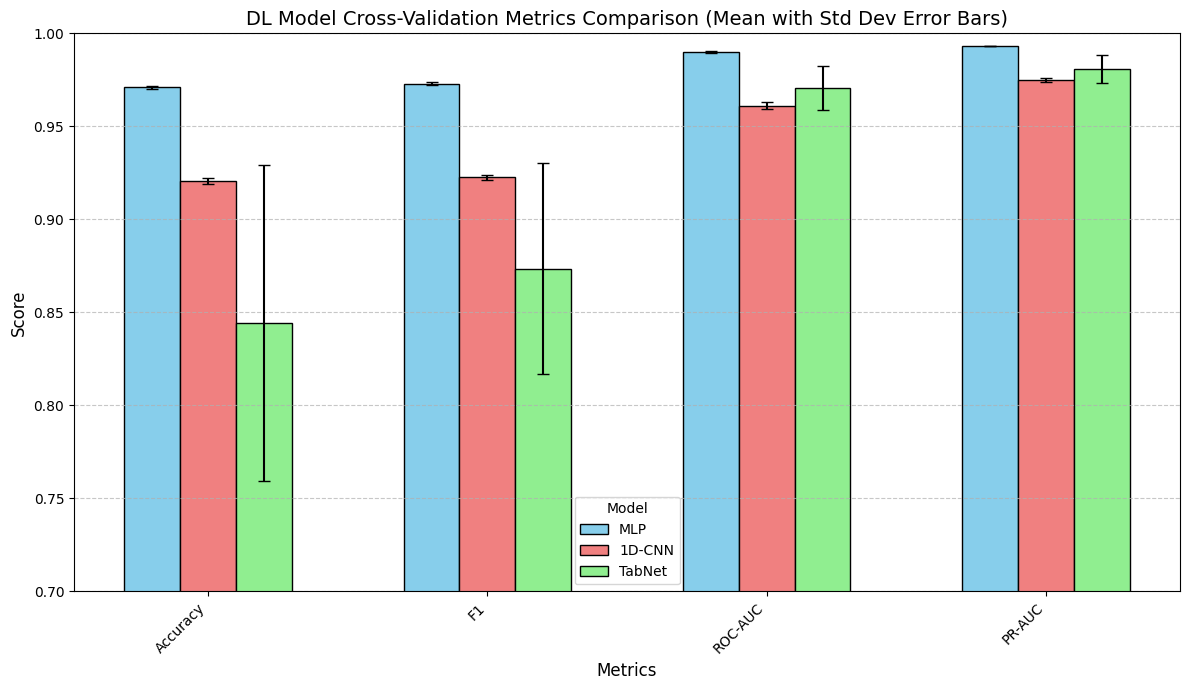

In [98]:
dl_cv_summary = pd.DataFrame({
    "MLP": mlp_cv_summary["Mean"],
    "1D-CNN": cnn_cv_summary["Mean"],
    "TabNet": tabnet_cv_summary["Mean"]
}).T

dl_cv_std = pd.DataFrame({
    "MLP": mlp_cv_summary["Std"],
    "1D-CNN": cnn_cv_summary["Std"],
    "TabNet": tabnet_cv_summary["Std"]
}).T

# Select key metrics for comparison
metrics_to_plot = ['Accuracy', 'F1', 'ROC-AUC', 'PR-AUC']

fig, ax = plt.subplots(figsize=(12, 7))

models = dl_cv_summary.index
bar_width = 0.2
index = np.arange(len(metrics_to_plot))

colors = ['skyblue', 'lightcoral', 'lightgreen']

for i, model in enumerate(models):
    means = dl_cv_summary.loc[model, metrics_to_plot]
    stds = dl_cv_std.loc[model, metrics_to_plot]
    ax.bar(index + i * bar_width, means, bar_width, yerr=stds, capsize=4, label=model, color=colors[i], edgecolor='black')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('DL Model Cross-Validation Metrics Comparison (Mean with Std Dev Error Bars)', fontsize=14)
ax.set_xticks(index + bar_width * (len(models) - 1) / 2)
ax.set_xticklabels(metrics_to_plot, rotation=45, ha='right', fontsize=10)
ax.set_ylim(0.7, 1.0) # Adjust y-axis limits for better visualization
ax.legend(title='Model', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [99]:
path_mlp = '/content/drive/MyDrive/Datasets/mlp_cv_summary.csv'
mlp_cv_summary.to_csv(path_mlp, index=True)
print(f'MLP summary saved to: {path_mlp}')

path_cnn = '/content/drive/MyDrive/Datasets/cnn_cv_summary.csv'
cnn_cv_summary.to_csv(path_cnn, index=True)
print(f'1D-CNN summary saved to: {path_cnn}')

path_tabnet = '/content/drive/MyDrive/Datasets/tabnet_cv_summary.csv'
tabnet_cv_summary.to_csv(path_tabnet, index=True)
print(f'TabNet summary saved to: {path_tabnet}')

path_tabnet = '/content/drive/MyDrive/Datasets/tabnet_cv_summary_v2.csv'
tabnet_cv_summary_v2.to_csv(path_tabnet, index=True)
print(f'TabNet (v2) summary saved to: {path_tabnet}')

MLP summary saved to: /content/drive/MyDrive/Datasets/mlp_cv_summary.csv
1D-CNN summary saved to: /content/drive/MyDrive/Datasets/cnn_cv_summary.csv
TabNet summary saved to: /content/drive/MyDrive/Datasets/tabnet_cv_summary.csv
TabNet (v2) summary saved to: /content/drive/MyDrive/Datasets/tabnet_cv_summary_v2.csv


# **All Model Comparison**

In [100]:
model_summaries = {
    "Random Forest": rf_cv_summary,
    "XGBoost": xgb_cv_summary,
    "LightGBM": lgbm_cv_summary,
    "KNN": knn_cv_summary,
    "Logistic Regression": lr_cv_summary,
    "Decision Tree": dt_cv_summary,
    "MLP": mlp_cv_summary,
    "1D-CNN": cnn_cv_summary,
    "TabNet": tabnet_cv_summary
}

cv_comparison = pd.DataFrame({
    model: summary["Mean"]
    for model, summary in model_summaries.items()
}).T

cv_comparison = cv_comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ]
]

cv_comparison

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Random Forest,0.979661,0.981342,0.981175,0.981257,0.996121,0.996776
XGBoost,0.980904,0.985269,0.979456,0.982353,0.997358,0.998108
LightGBM,0.981846,0.985936,0.980535,0.983227,0.997543,0.998232
KNN,0.974868,0.978555,0.975057,0.976801,0.989649,0.987364
Logistic Regression,0.876143,0.940614,0.823800,0.878331,0.918783,0.943574
Decision Tree,0.976505,0.978286,0.978428,0.978354,0.976326,0.968886
MLP,0.970899,0.980235,0.965855,0.972989,0.989803,0.993205
1D-CNN,0.920709,0.981744,0.870062,0.922535,0.960991,0.974948
TabNet,0.844417,0.818036,0.952408,0.873509,0.970471,0.980865


In [101]:
cv_comparison_percent = (
    cv_comparison * 100
).round(2)

cv_comparison_percent

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Random Forest,97.97,98.13,98.12,98.13,99.61,99.68
XGBoost,98.09,98.53,97.95,98.24,99.74,99.81
LightGBM,98.18,98.59,98.05,98.32,99.75,99.82
KNN,97.49,97.86,97.51,97.68,98.96,98.74
Logistic Regression,87.61,94.06,82.38,87.83,91.88,94.36
Decision Tree,97.65,97.83,97.84,97.84,97.63,96.89
MLP,97.09,98.02,96.59,97.30,98.98,99.32
1D-CNN,92.07,98.17,87.01,92.25,96.10,97.49
TabNet,84.44,81.80,95.24,87.35,97.05,98.09


In [102]:
cv_comparison_std = pd.DataFrame({
    model: summary["Std"]
    for model, summary in model_summaries.items()
}).T

cv_comparison_std = cv_comparison_std[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ]
]

(cv_comparison_std * 100).round(2)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Random Forest,0.08,0.09,0.22,0.08,0.03,0.03
XGBoost,0.07,0.09,0.15,0.07,0.03,0.01
LightGBM,0.06,0.07,0.16,0.06,0.02,0.01
KNN,0.12,0.07,0.26,0.11,0.07,0.10
Logistic Regression,0.27,0.59,0.16,0.23,0.15,0.29
Decision Tree,0.07,0.23,0.16,0.06,0.08,0.17
MLP,0.08,0.24,0.17,0.07,0.05,0.02
1D-CNN,0.14,0.10,0.20,0.15,0.19,0.13
TabNet,8.49,12.35,4.82,5.66,1.17,0.76


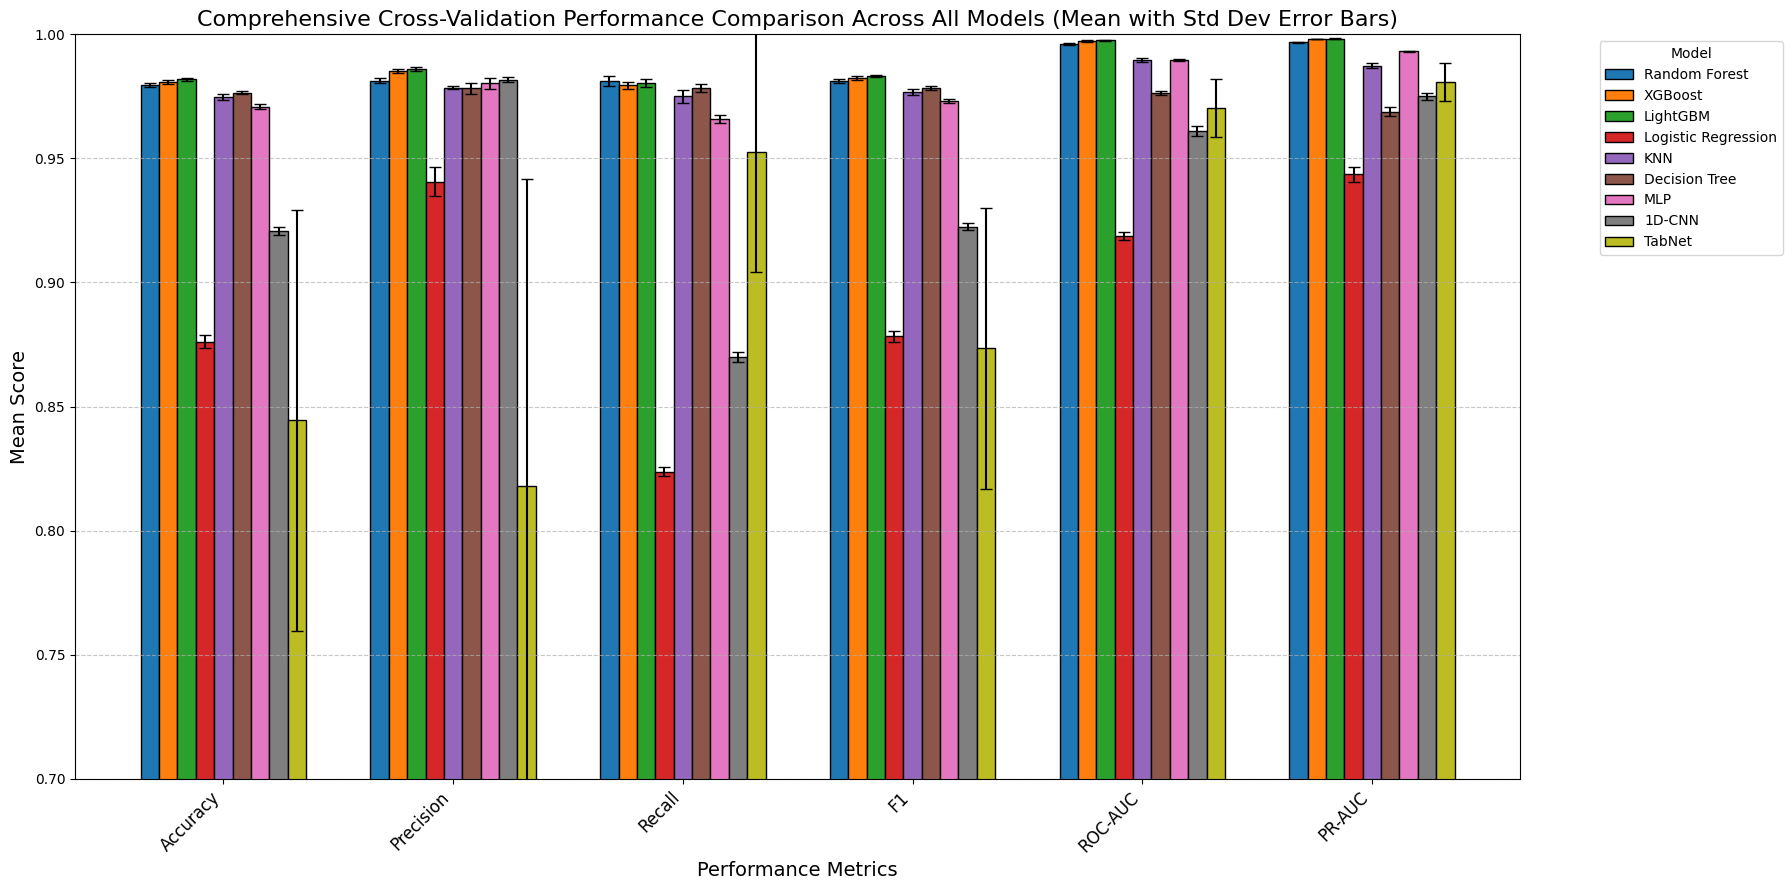

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine ML and DL summaries for a complete comparison
all_models_mean = pd.concat([ml_cv_summary, dl_cv_summary])
all_models_std = pd.concat([ml_cv_std, dl_cv_std])

# Filter for common metrics (excluding 'Training_Time_sec' for the mean plot)
metrics_to_plot_all = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']

fig, ax = plt.subplots(figsize=(18, 9))

models = all_models_mean.index
bar_width = 0.08  # Adjusted bar width for more models
index = np.arange(len(metrics_to_plot_all))

# Define a color palette for all models
colors = sns.color_palette('tab10', len(models))

for i, model in enumerate(models):
    means = all_models_mean.loc[model, metrics_to_plot_all]
    stds = all_models_std.loc[model, metrics_to_plot_all]
    ax.bar(index + i * bar_width, means, bar_width, yerr=stds, capsize=4, label=model, color=colors[i], edgecolor='black')

ax.set_xlabel('Performance Metrics', fontsize=14)
ax.set_ylabel('Mean Score', fontsize=14)
ax.set_title('Comprehensive Cross-Validation Performance Comparison Across All Models (Mean with Std Dev Error Bars)', fontsize=16)
ax.set_xticks(index + bar_width * (len(models) - 1) / 2)
ax.set_xticklabels(metrics_to_plot_all, rotation=45, ha='right', fontsize=12)
ax.set_ylim(0.7, 1.0)  # Adjust y-axis limits to better visualize differences
ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# **12. Final Model Training and Test Evaluaton**

In [104]:
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining attack ratio:", y_train.mean())
print("Test attack ratio:", y_test.mean())

Training shape: (109344, 65)
Test shape: (27337, 65)

Training attack ratio: 0.5426543751829089
Test attack ratio: 0.542634524636939


 *Final Pre-processing*

In [105]:
# Final Preprocessing

final_imputer = SimpleImputer(
    strategy="median"
)

X_train_imp = final_imputer.fit_transform(
    X_train
)

X_test_imp = final_imputer.transform(
    X_test
)

final_scaler = StandardScaler()

X_train_scaled = final_scaler.fit_transform(
    X_train_imp
)

X_test_scaled = final_scaler.transform(
    X_test_imp
)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (109344, 65)
X_test_scaled: (27337, 65)


 ***Final RF***

In [106]:
# Final Random Forest

final_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

start_time = time.time()

final_rf.fit(
    X_train_imp,
    y_train
)

rf_training_time = time.time() - start_time

rf_test_prob = final_rf.predict_proba(
    X_test_imp
)[:, 1]

rf_test_pred = (
    rf_test_prob >= 0.5
).astype(int)

print(
    f"Training time: {rf_training_time:.2f} sec"
)

Training time: 51.93 sec


 ***Final XGBoost***

In [107]:
# Final XGBoost

final_xgb = XGBClassifier(
    n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
)

start_time = time.time()

final_xgb.fit(
    X_train_imp,
    y_train
)

xgb_training_time = time.time() - start_time

xgb_test_prob = final_xgb.predict_proba(
    X_test_imp
)[:, 1]

xgb_test_pred = (
    xgb_test_prob >= 0.5
).astype(int)

print(
    f"Training time: {xgb_training_time:.2f} sec"
)

Training time: 4.49 sec


***Final LightGBM***

In [108]:
# Final LightGBM

final_lgbm = LGBMClassifier(
    n_estimators=200,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
)

start_time = time.time()

final_lgbm.fit(
    X_train_imp,
    y_train
)

lgbm_training_time = time.time() - start_time

lgbm_test_prob = final_lgbm.predict_proba(
    X_test_imp
)[:, 1]

lgbm_test_pred = (
    lgbm_test_prob >= 0.5
).astype(int)

print(
    f"Training time: {lgbm_training_time:.2f} sec"
)

Training time: 4.85 sec


***Final Logistic Regression***

In [109]:
# Final Logistic Regression

final_lr = LogisticRegression(
    max_iter=1000,
        random_state=RANDOM_STATE,
        n_jobs=-1
)

start_time = time.time()

final_lr.fit(
    X_train_imp,
    y_train
)

lr_training_time = time.time() - start_time

lr_test_prob = final_lr.predict_proba(
    X_test_imp
)[:, 1]

lr_test_pred = (
    lr_test_prob >= 0.5
).astype(int)

print(
    f"Training time: {lr_training_time:.2f} sec"
)

Training time: 19.16 sec


**Final KNN***

In [110]:
# Final KNN
final_knn = KNeighborsClassifier()

start_time = time.time()

final_knn.fit(
    X_train_imp,
    y_train
)

knn_training_time = time.time() - start_time

knn_test_prob = final_knn.predict_proba(
    X_test_imp
)[:, 1]

knn_test_pred = (
    knn_test_prob >= 0.5
).astype(int)

print(
    f"Training time: {knn_training_time:.2f} sec"
)

Training time: 0.03 sec


***Final Decission Tree***

In [111]:
# Final Decision Tree

final_dt = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

start_time = time.time()

final_dt.fit(
    X_train_imp,
    y_train
)

dt_training_time = time.time() - start_time

dt_test_prob = final_dt.predict_proba(
    X_test_imp
)[:, 1]

dt_test_pred = (
    dt_test_prob >= 0.5
).astype(int)

print(
    f"Training time: {dt_training_time:.2f} sec"
)

Training time: 5.60 sec


***Final MLP***

In [112]:
# Final MLP Training

final_mlp = MLP(
    input_dim=X_train_scaled.shape[1]
)

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.to_numpy(),
    dtype=torch.float32
).reshape(-1, 1)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True
)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    final_mlp.parameters(),
    lr=0.001
)

final_mlp.to(device)

start_time = time.time()

for epoch in range(30):

    final_mlp.train()

    for batch_X, batch_y in train_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = final_mlp(batch_X)

        loss = criterion(
            outputs,
            batch_y
        )

        loss.backward()
        optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1}/30 "
            f"Loss: {loss.item():.4f}"
        )

mlp_training_time = time.time() - start_time

Epoch 5/30 Loss: 0.1812
Epoch 10/30 Loss: 0.1232
Epoch 15/30 Loss: 0.1266
Epoch 20/30 Loss: 0.1661
Epoch 25/30 Loss: 0.1404
Epoch 30/30 Loss: 0.1265


In [113]:
final_mlp.eval()

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
).to(device)

with torch.no_grad():

    logits = final_mlp(
        X_test_tensor
    )

    mlp_test_prob = torch.sigmoid(
        logits
    ).cpu().numpy().ravel()

mlp_test_pred = (
    mlp_test_prob >= 0.5
).astype(int)

***Final 1D-CNN***

In [114]:
# Final 1D-CNN

final_cnn = CNN1D(
    input_dim=X_train_scaled.shape[1]
)

X_train_cnn = X_train_scaled[:, np.newaxis, :]
X_test_cnn = X_test_scaled[:, np.newaxis, :]

X_train_tensor = torch.tensor(
    X_train_cnn,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.to_numpy(),
    dtype=torch.float32
).reshape(-1, 1)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True
)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    final_cnn.parameters(),
    lr=0.001
)

final_cnn.to(device)

start_time = time.time()

for epoch in range(30):

    final_cnn.train()

    for batch_X, batch_y in train_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = final_cnn(batch_X)

        loss = criterion(
            outputs,
            batch_y
        )

        loss.backward()
        optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1}/30 "
            f"Loss: {loss.item():.4f}"
        )

cnn_training_time = time.time() - start_time

Epoch 5/30 Loss: 0.2320
Epoch 10/30 Loss: 0.2663
Epoch 15/30 Loss: 0.2762
Epoch 20/30 Loss: 0.2249
Epoch 25/30 Loss: 0.2539
Epoch 30/30 Loss: 0.2506


In [115]:
final_cnn.eval()

X_test_tensor = torch.tensor(
    X_test_cnn,
    dtype=torch.float32
).to(device)

with torch.no_grad():

    logits = final_cnn(
        X_test_tensor
    )

    cnn_test_prob = torch.sigmoid(
        logits
    ).cpu().numpy().ravel()

cnn_test_pred = (
    cnn_test_prob >= 0.5
).astype(int)

***Final TabNet***

In [116]:
# Final TabNet

final_tabnet = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=3,
    gamma=1.5,
    lambda_sparse=1e-4,

    optimizer_fn=torch.optim.Adam,

    optimizer_params=dict(
        lr=0.02
    ),

    mask_type="entmax",

    seed=RANDOM_STATE,

    verbose=0
)

start_time = time.time()

final_tabnet.fit(
    X_train_scaled,
    y_train.to_numpy(),

    max_epochs=30,

    batch_size=1024,

    virtual_batch_size=128,

    num_workers=0,

    drop_last=False
)

tabnet_training_time = time.time() - start_time

tabnet_test_prob = final_tabnet.predict_proba(
    X_test_scaled
)[:, 1]

tabnet_test_pred = (
    tabnet_test_prob >= 0.5
).astype(int)

# **13.Final Test Metrics**

In [117]:
# Test Evaluation Function

def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_prob
):

    return {
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred
        ),

        "Recall": recall_score(
            y_true,
            y_pred
        ),

        "F1": f1_score(
            y_true,
            y_pred
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            y_prob
        ),

        "PR-AUC": average_precision_score(
            y_true,
            y_prob
        )
    }

In [118]:
# Final Test Results

test_results = []

test_results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_test_pred,
        rf_test_prob
    )
)

test_results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_test_pred,
        xgb_test_prob
    )
)

test_results.append(
    evaluate_model(
        "LightGBM",
        y_test,
        lgbm_test_pred,
        lgbm_test_prob
    )
)

test_results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_test_pred,
        lr_test_prob
    )
)

test_results.append(
    evaluate_model(
        "KNN",
        y_test,
        knn_test_pred,
        knn_test_prob
    )
)

test_results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_test_pred,
        dt_test_prob
    )
)

test_results.append(
    evaluate_model(
        "MLP",
        y_test,
        mlp_test_pred,
        mlp_test_prob
    )
)

test_results.append(
    evaluate_model(
        "1D-CNN",
        y_test,
        cnn_test_pred,
        cnn_test_prob
    )
)

test_results.append(
    evaluate_model(
        "TabNet",
        y_test,
        tabnet_test_pred,
        tabnet_test_prob
    )
)

final_test_results_df = pd.DataFrame(
    test_results
)

final_test_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,0.980210,0.981149,0.982405,0.981777,0.996271,0.996811
1,XGBoost,0.981966,0.986697,0.979978,0.983326,0.997604,0.998260
2,LightGBM,0.983173,0.987783,0.981124,0.984443,0.997674,0.998294
3,Logistic Regression,0.879833,0.941780,0.829850,0.882279,0.921223,0.945846
4,KNN,0.976223,0.978478,0.977686,0.978082,0.990153,0.987827
5,Decision Tree,0.975930,0.977114,0.978563,0.977838,0.975724,0.967864
6,MLP,0.969126,0.975915,0.966968,0.971421,0.989132,0.992721
7,1D-CNN,0.920181,0.973858,0.876433,0.922580,0.959958,0.974168
8,TabNet,0.712368,0.659148,0.973170,0.785953,0.945170,0.965754


In [119]:
final_test_results_percent = (
    final_test_results_df
    .set_index("Model")
    * 100
).round(2)

final_test_results_percent

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
Random Forest,98.02,98.11,98.24,98.18,99.63,99.68
XGBoost,98.20,98.67,98.00,98.33,99.76,99.83
LightGBM,98.32,98.78,98.11,98.44,99.77,99.83
Logistic Regression,87.98,94.18,82.99,88.23,92.12,94.58
KNN,97.62,97.85,97.77,97.81,99.02,98.78
Decision Tree,97.59,97.71,97.86,97.78,97.57,96.79
MLP,96.91,97.59,96.70,97.14,98.91,99.27
1D-CNN,92.02,97.39,87.64,92.26,96.00,97.42
TabNet,71.24,65.91,97.32,78.60,94.52,96.58


In [120]:
path_final_test_results = '/content/drive/MyDrive/Datasets/final_test_results.csv'
final_test_results_percent.to_csv(path_final_test_results, index=True)
print(f'Final test results saved to: {path_final_test_results}')

Final test results saved to: /content/drive/MyDrive/Datasets/final_test_results.csv


## **Confusion Metrics**

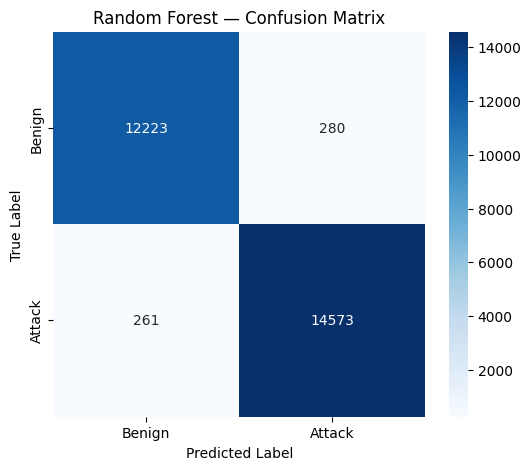

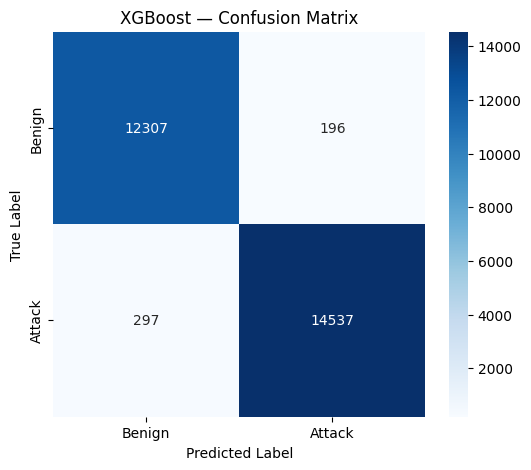

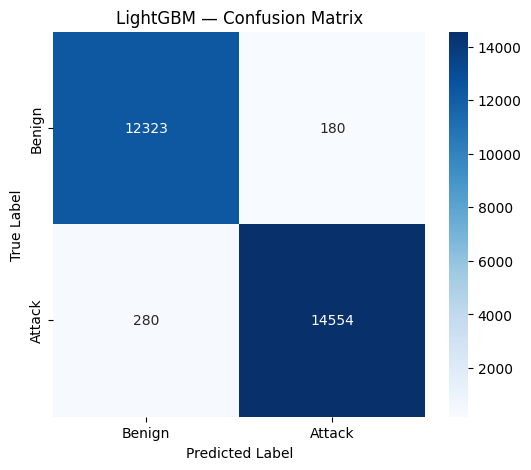

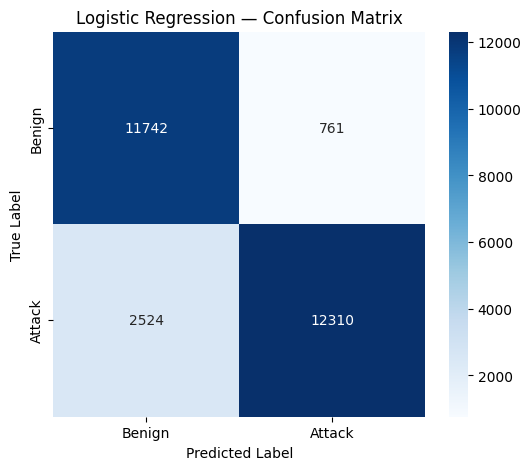

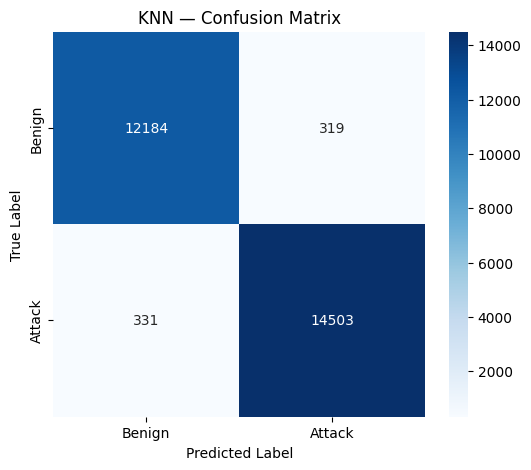

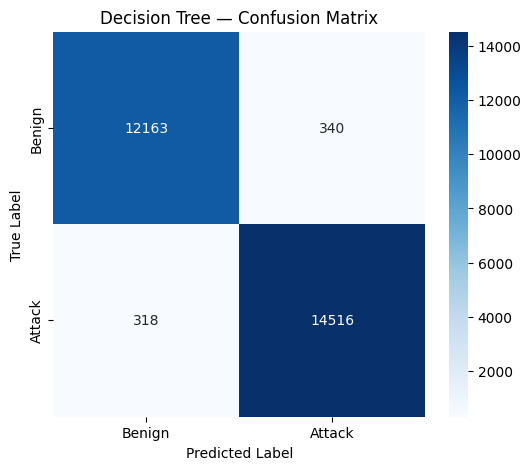

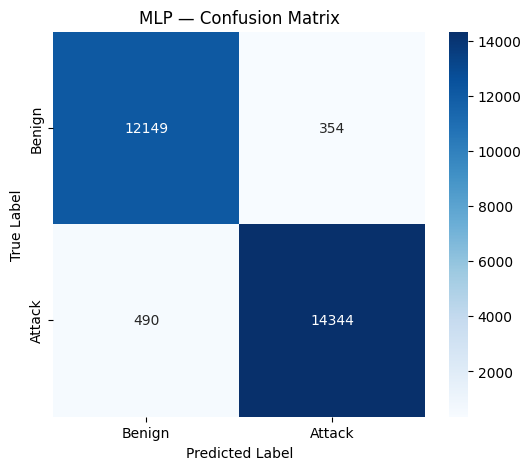

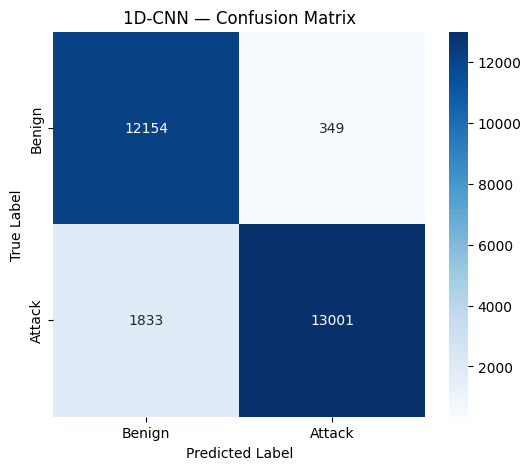

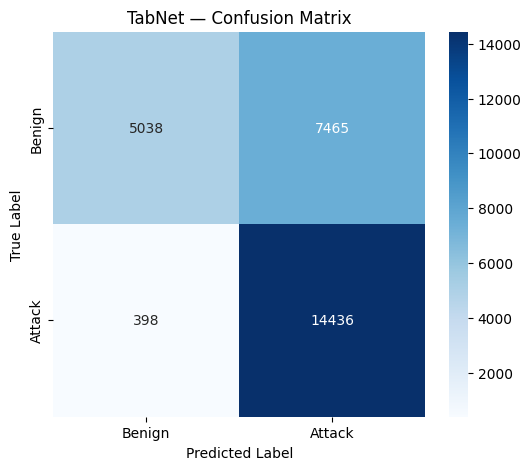

In [121]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

final_predictions = {
    "Random Forest": rf_test_pred,
    "XGBoost": xgb_test_pred,
    "LightGBM": lgbm_test_pred,
    "Logistic Regression": lr_test_pred,
    "KNN": knn_test_pred,
    "Decision Tree": dt_test_pred,
    "MLP": mlp_test_pred,
    "1D-CNN": cnn_test_pred,
    "TabNet": tabnet_test_pred
}

for model_name, predictions in final_predictions.items():

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Benign", "Attack"],
        yticklabels=["Benign", "Attack"]
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{model_name} — Confusion Matrix")

    plt.show()

## **ROC Curve**

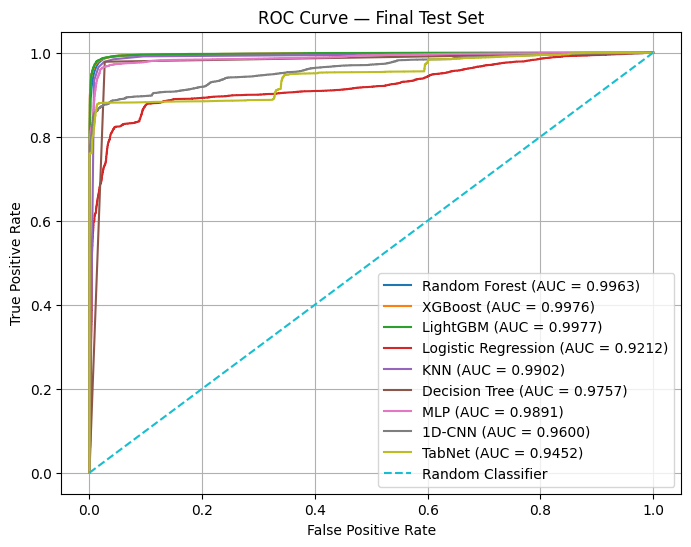

In [122]:
from sklearn.metrics import roc_curve, auc

model_probabilities = {
    "Random Forest": rf_test_prob,
    "XGBoost": xgb_test_prob,
    "LightGBM": lgbm_test_prob,
    "Logistic Regression": lr_test_prob,
    "KNN": knn_test_prob,
    "Decision Tree": dt_test_prob,
    "MLP": mlp_test_prob,
    "1D-CNN": cnn_test_prob,
    "TabNet": tabnet_test_prob
}

plt.figure(figsize=(8, 6))

for model_name, probabilities in model_probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {roc_auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Test Set")
plt.legend()
plt.grid(True)

plt.show()

## **Precission - Recall Curve**

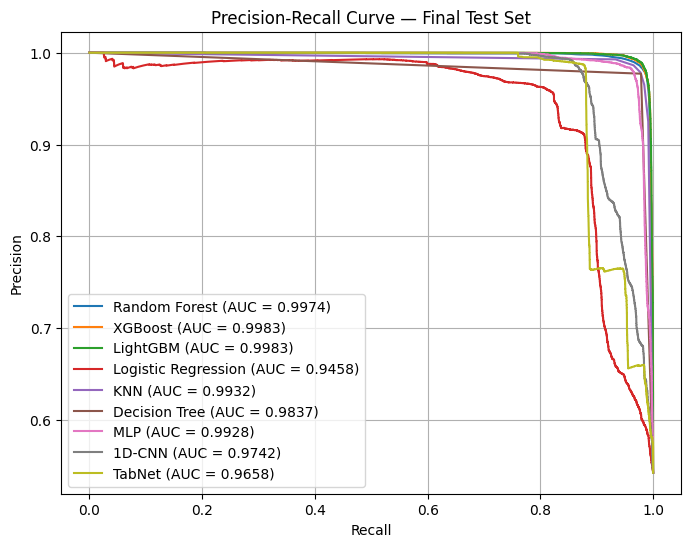

In [123]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 6))

for model_name, probabilities in model_probabilities.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities
    )

    pr_auc = auc(
        recall,
        precision
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (AUC = {pr_auc:.4f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Final Test Set")
plt.legend()
plt.grid(True)

plt.show()

In [124]:
final_ranking = (
    final_test_results_df
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

final_ranking

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,LightGBM,0.983173,0.987783,0.981124,0.984443,0.997674,0.998294
1,XGBoost,0.981966,0.986697,0.979978,0.983326,0.997604,0.998260
2,Random Forest,0.980210,0.981149,0.982405,0.981777,0.996271,0.996811
3,KNN,0.976223,0.978478,0.977686,0.978082,0.990153,0.987827
4,Decision Tree,0.975930,0.977114,0.978563,0.977838,0.975724,0.967864
5,MLP,0.969126,0.975915,0.966968,0.971421,0.989132,0.992721
6,1D-CNN,0.920181,0.973858,0.876433,0.922580,0.959958,0.974168
7,Logistic Regression,0.879833,0.941780,0.829850,0.882279,0.921223,0.945846
8,TabNet,0.712368,0.659148,0.973170,0.785953,0.945170,0.965754


# **14. xAI - SHAP**

In [125]:
!pip install -q shap
import shap

## ***LightGBM SHAP***

In [126]:
explainer_lgbm = shap.TreeExplainer(
    final_lgbm
)
X_shap = X_test_imp[:5000]

shap_values_lgbm = explainer_lgbm.shap_values(
    X_shap
)

print("SHAP calculation done.")

SHAP calculation done.


In [127]:
type(shap_values_lgbm)

numpy.ndarray

In [128]:
np.shape(shap_values_lgbm)

(5000, 65)

In [129]:
# GLOBAL SHAP feature importance

shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean_Absolute_SHAP": np.abs(
        shap_values_lgbm
    ).mean(axis=0)
})

shap_importance = (
    shap_importance.sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    ).reset_index(drop=True)
)

shap_importance.head(20)

,Feature,Mean_Absolute_SHAP
0,Fwd IAT Std,1.773927
1,Dst Port,1.034484
2,Bwd IAT Tot,0.466957
3,Bwd IAT Min,0.462947
4,Init Bwd Win Byts,0.425971
5,Bwd Pkts/s,0.335696
6,Fwd Header Len,0.286309
7,Fwd IAT Min,0.263343
8,TotLen Bwd Pkts,0.235566
9,Fwd IAT Tot,0.225702


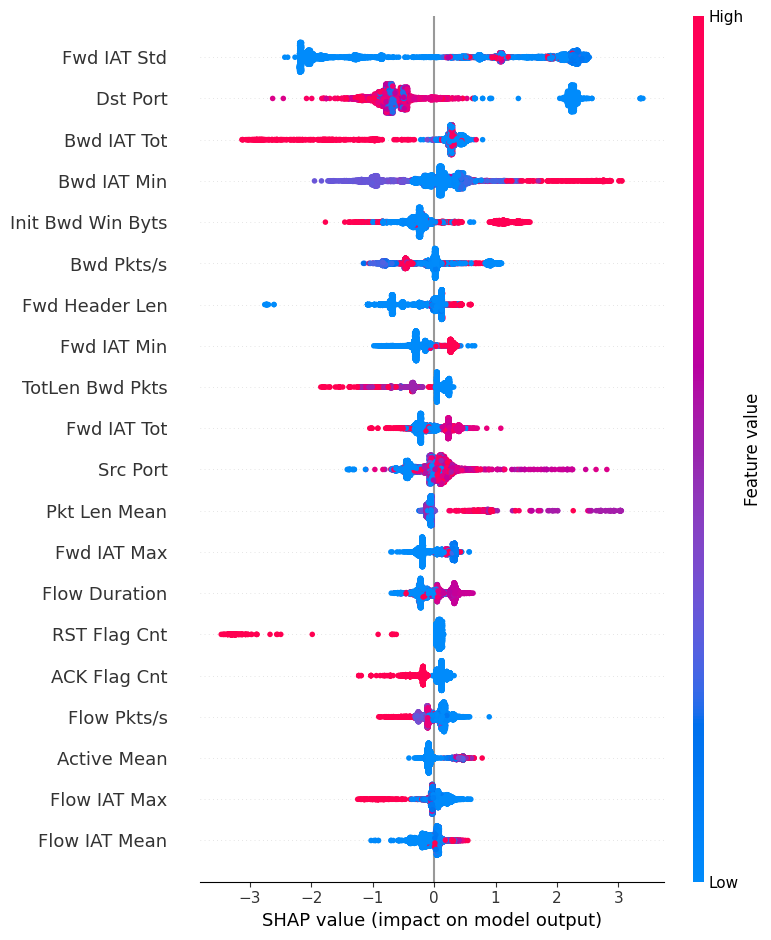

In [130]:
shap.summary_plot(
    shap_values_lgbm,
    X_shap,
    feature_names=X.columns,
    max_display=20
)

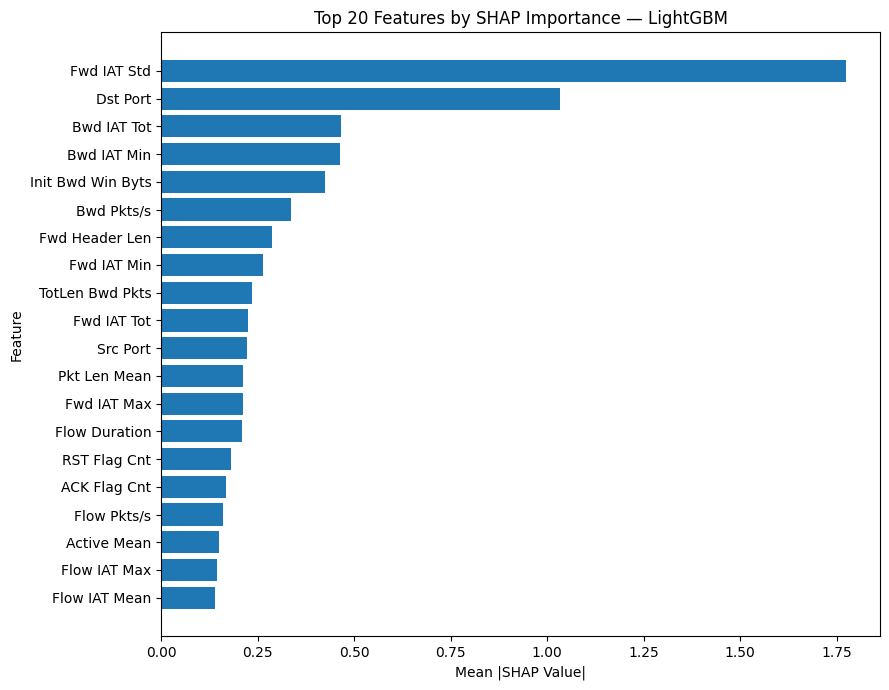

In [131]:
top_features = shap_importance.head(20)

plt.figure(figsize=(9, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Mean_Absolute_SHAP"][::-1]
)

plt.xlabel("Mean |SHAP Value|")
plt.ylabel("Feature")
plt.title(
    "Top 20 Features by SHAP Importance — LightGBM"
)

plt.tight_layout()
plt.show()

In [132]:
lgbm_shap_path = "/content/drive/MyDrive/Datasets/lgbm_shap.csv"
shap_importance.to_csv(
    lgbm_shap_path,
    index=False
)
print(f"LightGBM SHAP saved to: {lgbm_shap_path}")

LightGBM SHAP saved to: /content/drive/MyDrive/Datasets/lgbm_shap.csv


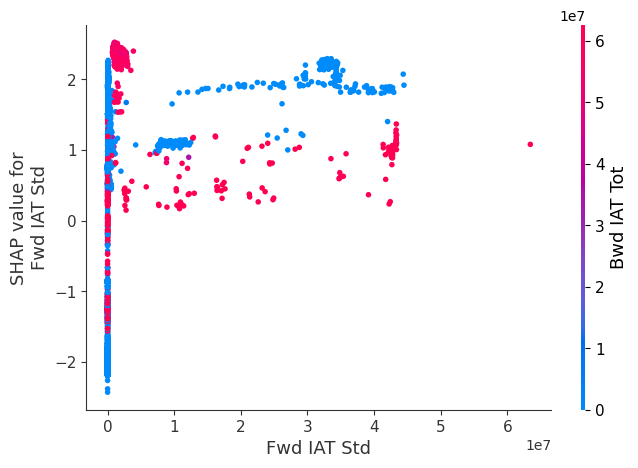

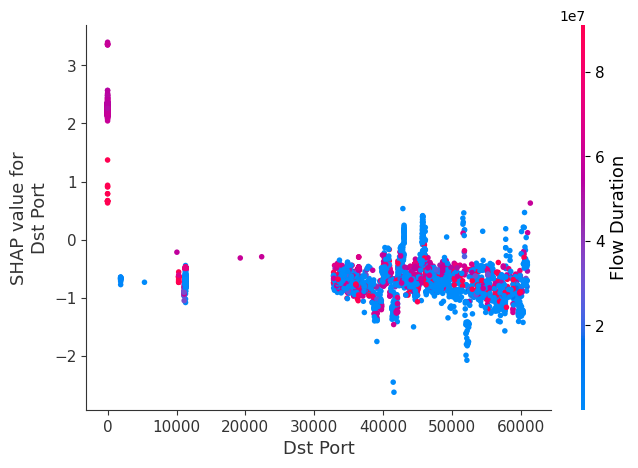

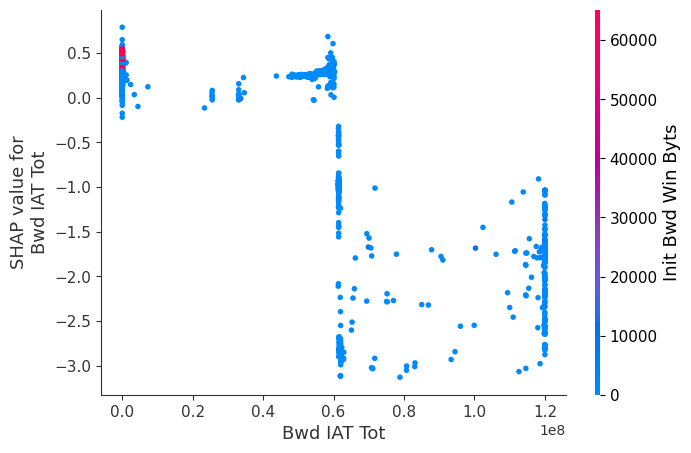

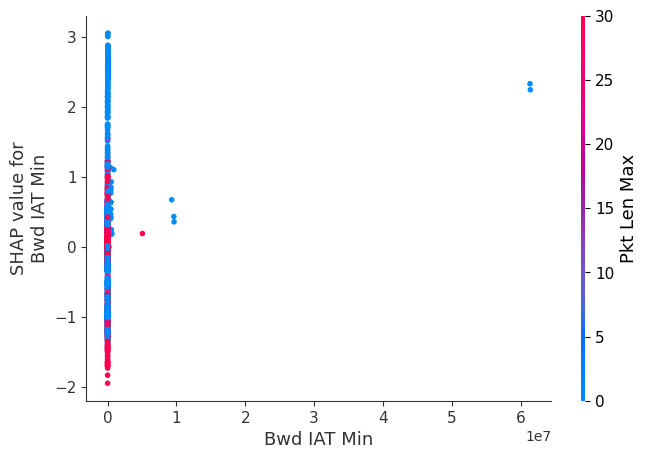

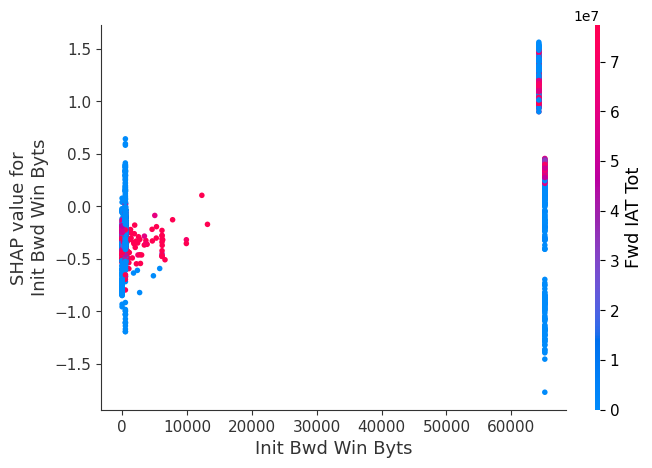

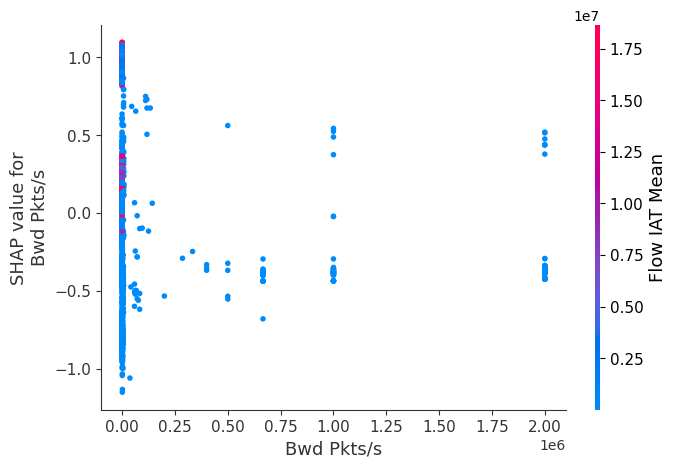

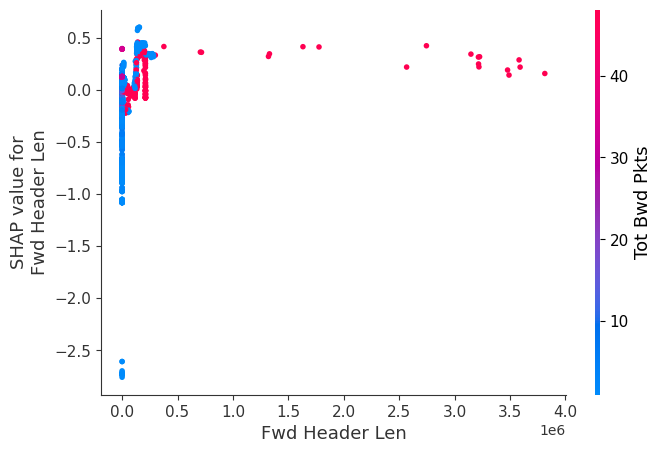

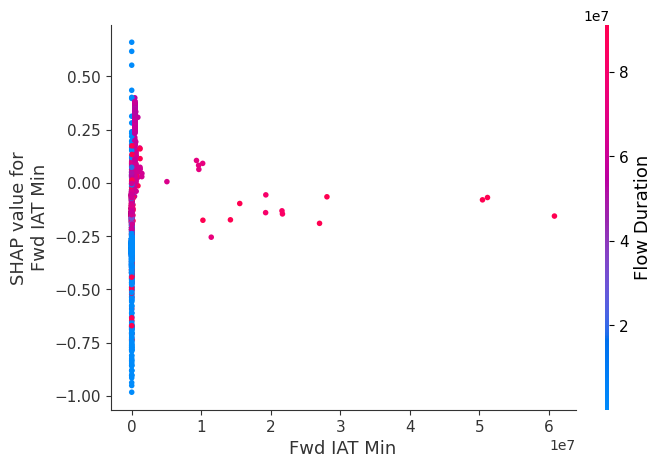

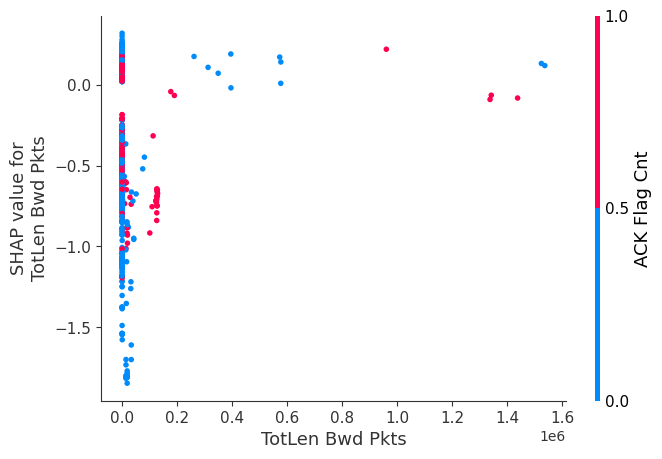

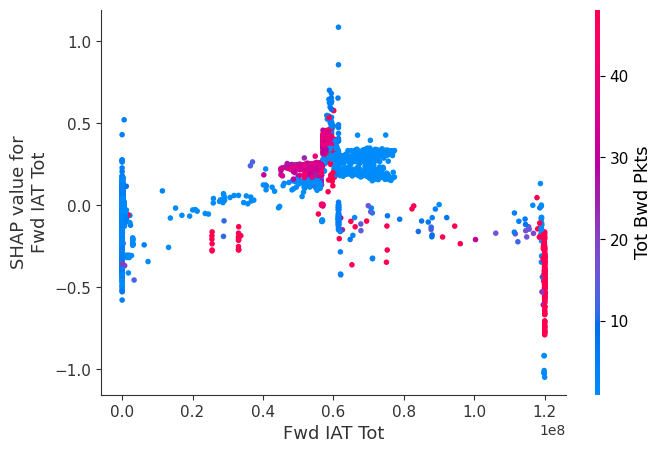

In [133]:
# Top 10 SHAP Dependence Plots

top_10_features = (
    shap_importance
    .head(10)["Feature"]
    .tolist()
)

for feature in top_10_features:

    shap.dependence_plot(
        feature,
        shap_values_lgbm,
        X_shap,
        feature_names=X.columns,
        show=True
    )

## ***Local Explanation***

In [139]:
attack_indices = np.where(
    y_test.to_numpy() == 1
)[0]

benign_indices = np.where(
    y_test.to_numpy() == 0
)[0]

attack_idx = attack_indices[0]
benign_idx = benign_indices[0]

print("Attack index:", attack_idx)
print("Benign index:", benign_idx)

Attack index: 2
Benign index: 0


In [140]:
explainer_lgbm = shap.TreeExplainer(
    final_lgbm
)

attack_explanation = explainer_lgbm(
    X_test_imp[attack_idx:attack_idx+1]
)

benign_explanation = explainer_lgbm(
    X_test_imp[benign_idx:benign_idx+1]
)

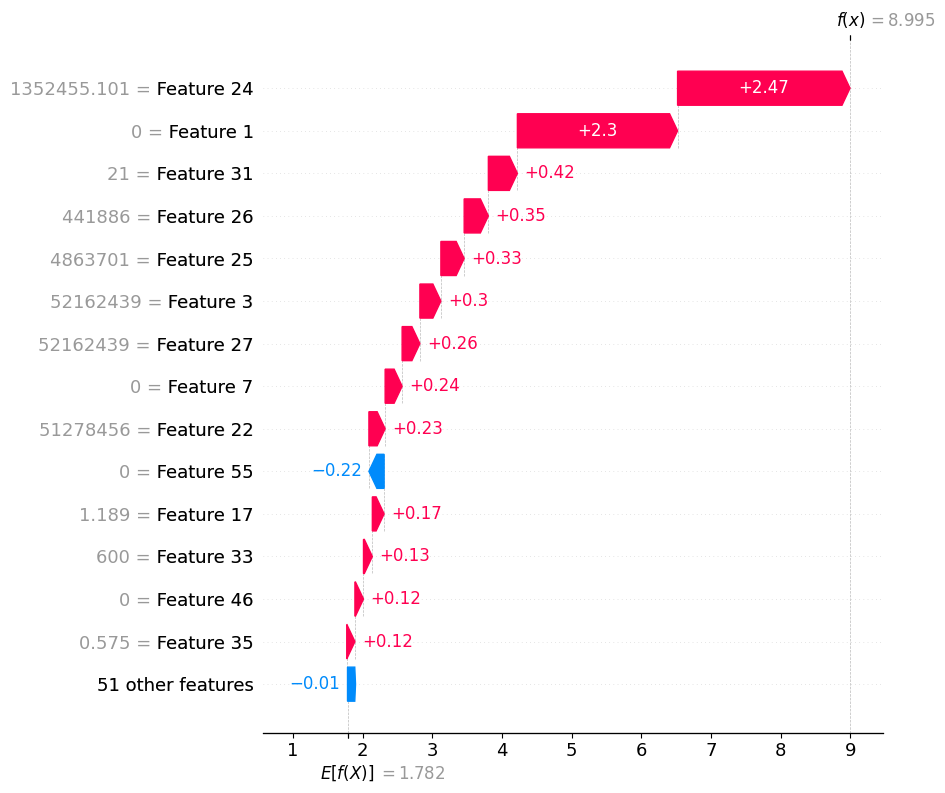

In [141]:
shap.plots.waterfall(
    attack_explanation[0],
    max_display=15
)

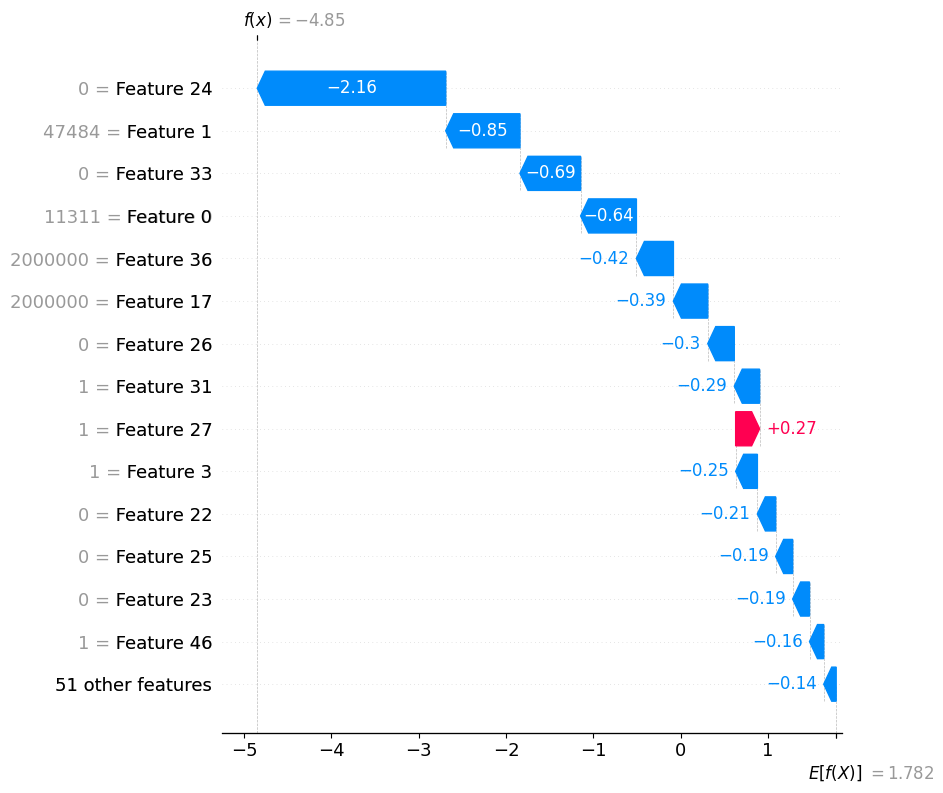

In [142]:
shap.plots.waterfall(
    benign_explanation[0],
    max_display=15
)